# NBFC Loan Default Prediction

By: **Lakshmi Devesh Kumar**

## Problem Statement

### Business Context

A non-banking financial institution (NBFI) or non-bank financial company (NBFC) is a Financial Institution that does not have a full banking license or is not supervised by a national or international banking regulatory agency. NBFC facilitates bank-related financial services, such as investment, risk pooling, contractual savings, and market brokering.
The following is the story of a challenge faced by DHDL Ltd. (Name Changed), an NBFC in India. In recent times, the company is struggling to mark profits due to an increase in Loan Defaults. The company aims to determine the relative importance of each parameter with regards to their contribution as to whether a loan is going to default or not. Provided is a sample that contains the data of 90,000 + clients who have taken a loan from the company in the past with the information on whether the loan defaulted.
The objective of this exercise is to understand which parameters play an important role in determining whether a client will default on the loan payment or not.

### Goal:
The goal of the problem is to predict whether a client will default on the loan payment or not. For each ID in the test_data, you must predict the “default” level.


### Datasets:
The problem contains two datasets, Train Data, and Test Data. Model building is to be done on Train Dataset and the Model testing is to be done on Test Dataset. The output from the Test Data is to be submitted in the Hackathon platform


### Metric to measure:
Your score is the percentage of all correct predictions made by you. This is simply known as accuracy. The best accuracy is 1 whereas the worst is 0. It will be calculated as the total number of two correct predictions (True positive + True negative) divided by the total number of observations in the dataset.

### Data Description

*	ID:	unique ID assigned to each applicant
*	loan_amnt:	loan amount ($) applied each applicant
*	loan_term:	Loan duration in years
*	interest_rate:	Applicable interest rate on Loan in %
*	loan_grade:	Loan Grade Assigned by the bank
*	loan_subgrade:	Loan SubGrade Assigned by the bank
*	job_experience:	Number of years job experience
*	home_ownership:	Status of House Ownership
*	annual_income:	Annual income of the applicant
*	income_verification_status:	Status of Income verification by the bank
*	loan_purpose:	Purpose of loan
*	state_code:	State code of the applicant's residence
*	debt_to_income:	Ratio to total debt to income (total debt might include other loan aswell)
*	delinq_2yrs:	number of 30+ days delinquency in past 2 years
*	public_records:	number of legal cases against the applicant
*	revolving_balance:	total credit revolving balance
*	total_acc:	total number of credit lines available in members credit line
*	interest_receive:	total interest received by the bank on the loan
*	application_type:	Whether the applicant has applied the loan by creating individuall or joint account
*	last_week_pay:	How many months have the applicant paid the loan EMI already
*	total_current_balance:	total current balance of all the accounts of applicant
*	total_revolving_limit:	total revolving credit limit
*	default:	status of loan amount, 1 = Defaulter, 0 = Non Defaulters


## Importing necessary libraries

In [602]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

#To help with reading and manipulating data
import pandas as pd
import numpy as np

#To help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#To help with missing value imputation
from sklearn.impute import SimpleImputer,KNNImputer

from sklearn.linear_model import LogisticRegression

#To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    StackingClassifier
)
import xgboost
from xgboost import XGBClassifier

#To help with metric scores
from sklearn import metrics
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

#To split data
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

#To be used for data scaling and one hot encoding
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder
)

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

#For model tuning
from sklearn.model_selection import(
    GridSearchCV,
    RandomizedSearchCV
)

# to create k folds of data and get cross validation score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

In [603]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Loading the dataset

In [604]:
#read the Train dataset
train_data = pd.read_csv('/content/drive/MyDrive/Python Course/Hackathon/Train_set.csv')


In [605]:
#read the Test dataset
test_data = pd.read_csv('/content/drive/MyDrive/Python Course/Hackathon/Test_set.csv')

## Data Overview

In [606]:
#Make a copy of the dataset data so that we do not accidentally make changes to the original dataset.
df_train = train_data.copy()

In [607]:
df_test = test_data.copy()

In [608]:
# Find the number of observations and features in the train dataset
df_train.shape
print("There are", df_train.shape[0], 'rows and', df_train.shape[1], "columns.")

There are 93174 rows and 23 columns.


In [609]:
# Find the number of observations and features in the test dataset
df_test.shape
print("There are", df_test.shape[0], 'rows and', df_test.shape[1], "columns.")

There are 39933 rows and 22 columns.


In [610]:
#Observe the first 10 df_train rows
df_train.head(10)

,ID,loan_amnt,loan_term,interest_rate,loan_grade,loan_subgrade,job_experience,home_ownership,annual_income,income_verification_status,...,delinq_2yrs,public_records,revolving_balance,total_acc,interest_receive,application_type,last_week_pay,total_current_balance,total_revolving_limit,default
0,72199369,9000,3 years,9.170,B,B2,<5 Years,OWN,85000.000,Not Verified,...,0.000,0.000,39519,20.000,59.600,INDIVIDUAL,4.000,95493.000,84100.000,0
1,14257956,18000,3 years,13.650,C,C1,<5 Years,OWN,64000.000,Verified,...,0.000,1.000,9783,24.000,3348.250,INDIVIDUAL,95.000,185433.000,13500.000,0
2,66216451,16000,3 years,7.260,A,A4,<5 Years,MORTGAGE,150000.000,Source Verified,...,2.000,0.000,13641,27.000,276.690,INDIVIDUAL,13.000,180519.000,19300.000,0
3,46974169,25000,3 years,13.990,C,C4,NaN,MORTGAGE,59800.000,Verified,...,0.000,0.000,35020,35.000,1106.720,INDIVIDUAL,17.000,183208.000,55400.000,0
4,46725961,17000,3 years,6.390,A,A2,10+ years,MORTGAGE,72000.000,Source Verified,...,0.000,0.000,23990,26.000,725.290,INDIVIDUAL,39.000,23990.000,81300.000,0
5,56469197,10000,3 years,12.690,C,C2,<5 Years,OWN,56000.000,Not Verified,...,0.000,1.000,6643,48.000,590.500,INDIVIDUAL,26.000,24054.000,25167.000,0
6,3409695,15000,3 years,11.140,B,B2,10+ years,RENT,100000.000,Not Verified,...,0.000,1.000,14088,14.000,1020.570,INDIVIDUAL,35.000,14519.000,15200.000,1
7,26276447,10000,3 years,6.490,A,A2,10+ years,MORTGAGE,109000.000,Not Verified,...,1.000,0.000,12337,26.000,728.680,INDIVIDUAL,74.000,210751.000,18600.000,0
8,48393405,12000,3 years,10.990,B,B4,<5 Years,RENT,45000.000,Verified,...,0.000,0.000,10550,12.000,879.150,INDIVIDUAL,39.000,10550.000,22000.000,0
9,15140624,7000,3 years,12.490,B,B4,<5 Years,MORTGAGE,53000.000,Not Verified,...,0.000,0.000,12108,20.000,1186.800,INDIVIDUAL,96.000,145801.000,16800.000,0


In [611]:
#Observe the last 10 df_train rows
df_train.tail(10)

,ID,loan_amnt,loan_term,interest_rate,loan_grade,loan_subgrade,job_experience,home_ownership,annual_income,income_verification_status,...,delinq_2yrs,public_records,revolving_balance,total_acc,interest_receive,application_type,last_week_pay,total_current_balance,total_revolving_limit,default
93164,22422347,22000,5 years,17.570,D,D4,10+ years,RENT,120000.000,Source Verified,...,3.000,0.000,18851,32.000,5236.900,INDIVIDUAL,78.000,36619.000,26600.000,0
93165,5257519,18000,5 years,15.800,C,C3,<5 Years,MORTGAGE,60000.000,Verified,...,0.000,0.000,15494,22.000,6228.140,INDIVIDUAL,144.000,54592.000,21606.000,0
93166,72107466,13000,3 years,12.590,C,C2,6-10 years,RENT,50000.000,Source Verified,...,0.000,0.000,19071,19.000,0.000,INDIVIDUAL,NaN,61289.000,29000.000,0
93167,53312784,7800,3 years,12.290,C,C1,NaN,MORTGAGE,21000.000,Verified,...,0.000,0.000,8197,8.000,479.810,INDIVIDUAL,31.000,93130.000,17200.000,0
93168,5819825,23850,5 years,21.000,E,E2,10+ years,MORTGAGE,90000.000,Verified,...,0.000,1.000,9954,10.000,10977.490,INDIVIDUAL,139.000,74395.000,12200.000,0
93169,65577252,3200,3 years,7.260,A,A4,<5 Years,RENT,85000.000,Not Verified,...,0.000,0.000,7924,38.000,55.340,INDIVIDUAL,13.000,64635.000,47600.000,0
93170,836021,3500,3 years,5.420,A,A1,NaN,MORTGAGE,57550.000,Not Verified,...,0.000,0.000,10174,24.000,299.670,INDIVIDUAL,161.000,NaN,NaN,1
93171,33058720,8000,3 years,13.980,C,C3,10+ years,RENT,148531.500,Source Verified,...,1.000,0.000,5391,25.000,1150.580,INDIVIDUAL,65.000,94596.000,6500.000,0
93172,4060472,35000,3 years,17.770,D,D1,<5 Years,RENT,100000.000,Verified,...,0.000,0.000,24609,45.000,5764.580,INDIVIDUAL,56.000,33759.000,34900.000,1
93173,3628127,10000,3 years,15.800,C,C3,<5 Years,RENT,60000.000,Verified,...,0.000,0.000,11285,7.000,2279.360,INDIVIDUAL,104.000,25594.000,12300.000,0


In [612]:
#Observe the first 10 df_test rows
df_test.head(10)

,ID,loan_amnt,loan_term,interest_rate,loan_grade,loan_subgrade,job_experience,home_ownership,annual_income,income_verification_status,...,debt_to_income,delinq_2yrs,public_records,revolving_balance,total_acc,interest_receive,application_type,last_week_pay,total_current_balance,total_revolving_limit
0,4855329,12000,3 years,15.310,C,C2,<5 Years,MORTGAGE,73400.000,Not Verified,...,14.620,0.000,0.000,22156,30.000,2290.240,INDIVIDUAL,87.000,128098.000,25800.000
1,66862420,12000,3 years,7.260,A,A4,10+ years,MORTGAGE,105000.000,Not Verified,...,11.380,0.000,0.000,7592,14.000,202.680,INDIVIDUAL,13.000,269396.000,23600.000
2,3637416,15000,3 years,14.330,C,C1,6-10 years,MORTGAGE,50000.000,Verified,...,28.150,0.000,1.000,17983,19.000,1166.240,INDIVIDUAL,30.000,220135.000,34100.000
3,53682249,12000,3 years,9.990,B,B3,6-10 years,RENT,37000.000,Source Verified,...,34.320,0.000,0.000,12262,18.000,635.060,INDIVIDUAL,35.000,39436.000,21700.000
4,53937165,20150,3 years,11.530,B,B5,<5 Years,RENT,75000.000,Source Verified,...,26.740,1.000,0.000,8251,11.000,1232.840,INDIVIDUAL,31.000,52764.000,12000.000
5,1464149,5850,3 years,12.120,B,B3,<5 Years,MORTGAGE,72000.000,Not Verified,...,23.140,0.000,0.000,16554,20.000,1155.780,INDIVIDUAL,156.000,NaN,NaN
6,7429943,18000,5 years,20.800,E,E1,<5 Years,RENT,45000.000,Verified,...,8.170,0.000,0.000,12282,19.000,2409.020,INDIVIDUAL,35.000,12282.000,45752.000
7,10047245,8575,3 years,23.100,E,E4,<5 Years,OWN,60000.000,Source Verified,...,21.010,0.000,2.000,4870,40.000,1085.560,INDIVIDUAL,35.000,73951.000,7800.000
8,46816125,15000,5 years,13.330,C,C3,6-10 years,MORTGAGE,40000.000,Source Verified,...,25.170,0.000,0.000,12687,22.000,1415.780,INDIVIDUAL,39.000,124171.000,21100.000
9,57125517,10000,3 years,12.690,C,C2,<5 Years,MORTGAGE,30000.000,Verified,...,5.760,0.000,0.000,5012,5.000,643.370,INDIVIDUAL,26.000,5012.000,5000.000


In [613]:
#Observe the last 10 df_test rows
df_test.tail(10)

,ID,loan_amnt,loan_term,interest_rate,loan_grade,loan_subgrade,job_experience,home_ownership,annual_income,income_verification_status,...,debt_to_income,delinq_2yrs,public_records,revolving_balance,total_acc,interest_receive,application_type,last_week_pay,total_current_balance,total_revolving_limit
39923,68349441,15000,3 years,10.990,B,B4,<5 Years,RENT,78555.960,Source Verified,...,21.830,0.000,0.000,20183,28.000,253.190,INDIVIDUAL,9.000,111761.000,24900.000
39924,49233466,35000,3 years,7.890,A,A5,<5 Years,RENT,175000.000,Source Verified,...,9.860,0.000,0.000,29403,24.000,1648.990,INDIVIDUAL,35.000,85771.000,57200.000
39925,26187138,16150,3 years,25.830,G,G2,6-10 years,MORTGAGE,45000.000,Verified,...,13.760,1.000,1.000,9595,15.000,4702.760,INDIVIDUAL,70.000,184738.000,12500.000
39926,30065386,20000,5 years,10.150,B,B2,<5 Years,MORTGAGE,97000.000,Source Verified,...,12.480,0.000,0.000,13871,28.000,2300.440,INDIVIDUAL,65.000,205416.000,17000.000
39927,43570955,5400,3 years,13.990,C,C4,<5 Years,RENT,45000.000,Verified,...,3.070,0.000,0.000,4763,4.000,584.120,INDIVIDUAL,43.000,4763.000,8700.000
39928,57779318,5000,3 years,8.180,B,B1,10+ years,MORTGAGE,65000.000,Source Verified,...,13.090,0.000,5.000,6731,24.000,187.270,INDIVIDUAL,26.000,14422.000,26100.000
39929,59742362,1800,3 years,11.530,B,B5,6-10 years,MORTGAGE,55000.000,Source Verified,...,25.440,0.000,1.000,11092,38.000,81.240,INDIVIDUAL,26.000,243469.000,29200.000
39930,72657145,15200,3 years,13.440,C,C3,10+ years,MORTGAGE,78000.000,Not Verified,...,19.400,0.000,0.000,19688,26.000,0.000,INDIVIDUAL,NaN,145370.000,45400.000
39931,15220189,14425,5 years,18.920,D,D4,<5 Years,MORTGAGE,38000.000,Not Verified,...,17.400,0.000,1.000,10805,29.000,4268.800,INDIVIDUAL,96.000,106449.000,19700.000
39932,21810584,27000,5 years,20.200,E,E3,<5 Years,MORTGAGE,62000.000,Source Verified,...,24.120,1.000,0.000,17795,17.000,7436.410,INDIVIDUAL,78.000,55787.000,33500.000


### Concise summary of the dataset

In [614]:
# Concise summary of df_train
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93174 entries, 0 to 93173
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          93174 non-null  int64  
 1   loan_amnt                   93174 non-null  int64  
 2   loan_term                   93174 non-null  object 
 3   interest_rate               93174 non-null  float64
 4   loan_grade                  93174 non-null  object 
 5   loan_subgrade               93174 non-null  object 
 6   job_experience              88472 non-null  object 
 7   home_ownership              93174 non-null  object 
 8   annual_income               93173 non-null  float64
 9   income_verification_status  93174 non-null  object 
 10  loan_purpose                93174 non-null  object 
 11  state_code                  93174 non-null  object 
 12  debt_to_income              93174 non-null  float64
 13  delinq_2yrs                 931

In [615]:
# Concise summary of df_test
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39933 entries, 0 to 39932
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          39933 non-null  int64  
 1   loan_amnt                   39933 non-null  int64  
 2   loan_term                   39933 non-null  object 
 3   interest_rate               39933 non-null  float64
 4   loan_grade                  39933 non-null  object 
 5   loan_subgrade               39933 non-null  object 
 6   job_experience              37844 non-null  object 
 7   home_ownership              39933 non-null  object 
 8   annual_income               39933 non-null  float64
 9   income_verification_status  39933 non-null  object 
 10  loan_purpose                39933 non-null  object 
 11  state_code                  39933 non-null  object 
 12  debt_to_income              39933 non-null  float64
 13  delinq_2yrs                 399

### Statistical Summary

In [616]:
# Statistical summary of df_train
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,93174.000,35050211.389,24149262.074,70735.000,10859832.500,37107507.000,58598949.500,73519746.000
loan_amnt,93174.000,14733.861,8428.185,500.000,8000.000,13000.000,20000.000,35000.000
interest_rate,93174.000,13.233,4.369,5.320,9.990,12.990,16.200,28.990
annual_income,93173.000,75028.259,69454.784,1200.000,45000.000,64000.000,90000.000,9500000.000
debt_to_income,93174.000,18.128,8.563,0.000,11.930,17.640,23.890,672.520
delinq_2yrs,93172.000,0.317,0.881,0.000,0.000,0.000,0.000,22.000
public_records,93172.000,0.196,0.581,0.000,0.000,0.000,0.000,49.000
revolving_balance,93174.000,16854.469,23689.074,0.000,6433.000,11856.000,20745.000,2560703.000
total_acc,93172.000,25.249,11.855,1.000,17.000,24.000,32.000,119.000
interest_receive,93174.000,1747.264,2088.236,0.000,439.880,1070.755,2219.613,23172.310


#### Observations:

* The ID column seems to be the unique column and we can drop this column during analysis.
* The loan amount min value is 500 , mean value is 14,733.861 and the max value is 35,000 rupees.
* The min, mean and max values of annual_income are 1,200, 75,028 and 95,00000 rupees
* The min, mean and max values of debt_to_income are 0.00, 18.128 and 672.52. This could have outliers.
* The min, mean and max values of delinq_2yrs are 0.00, 0.317 and 22.00. This could have outliers.
* The min, mean and max values of public_records are 0.00, 0.196 and 49.00. This could have outliers.
* The min, mean and max values of revolving_balance are 0.00, 16854.469 and 2560703.000. This could have outliers.
* The min, mean and max values of total_acc are 1.00, 25.249 and 119.000.
* The min, mean and max values of interest_receive are 0.00, 1747.264 and 23172.310.
* The min, mean and max values of last_week_pay are 0.00, 58.155 and 291.
* The min, mean and max values of total_current_balance are 0.00, 139252.923 and 8000078.000. This could have outliers.
* The min, mean and max values of total_revolving_limit are 0.00, 32085.903 and 9999999.000. This could have outliers.

In [617]:
# Statistical summary of df_test
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,39933.000,34811489.370,24217502.295,74301.000,10751721.000,36805086.000,58459985.000,73519693.000
loan_amnt,39933.000,14781.987,8427.845,500.000,8000.000,13000.000,20000.000,35000.000
interest_rate,39933.000,13.219,4.392,5.320,9.990,12.990,16.200,28.990
annual_income,39933.000,75264.800,56556.664,3300.000,45262.000,65000.000,90000.000,5000000.000
debt_to_income,39933.000,18.121,8.488,0.000,11.960,17.610,23.880,380.530
delinq_2yrs,39932.000,0.312,0.855,0.000,0.000,0.000,0.000,17.000
public_records,39932.000,0.192,0.558,0.000,0.000,0.000,0.000,23.000
revolving_balance,39933.000,17019.281,26129.745,0.000,6482.000,11949.000,20928.000,2568995.000
total_acc,39932.000,25.265,11.769,1.000,17.000,24.000,32.000,114.000
interest_receive,39933.000,1764.744,2095.443,0.000,441.470,1077.720,2260.990,21811.290


In [618]:
# Statistical summary of df_train for object type columns
df_train.describe(include=["object"]).T

,count,unique,top,freq
loan_term,93174,2,3 years,65211
loan_grade,93174,7,B,26865
loan_subgrade,93174,35,B3,5879
job_experience,88472,3,<5 Years,40610
home_ownership,93174,5,MORTGAGE,46445
income_verification_status,93174,3,Source Verified,34487
loan_purpose,93174,4,debt_consolidation,55241
state_code,93174,50,CA,13744
application_type,93174,2,INDIVIDUAL,93118


In [619]:
# Statistical summary of df_test for object type columns
df_test.describe(include=["object"]).T

,count,unique,top,freq
loan_term,39933,2,3 years,28110
loan_grade,39933,7,B,11551
loan_subgrade,39933,35,B3,2547
job_experience,37844,3,<5 Years,17290
home_ownership,39933,5,MORTGAGE,20008
income_verification_status,39933,3,Source Verified,14780
loan_purpose,39933,4,debt_consolidation,23473
state_code,39933,50,CA,5931
application_type,39933,2,INDIVIDUAL,39909


#### Observations:

* In the train dataset, we can observe that there is a column called "default" which is the target variable. But, this target variable is not there in the test dataset. We need to add this column in the test dataset.
* There are a total of 93174 rows and 23 columns in the train dataset.
* There are a total of 39933 rows and 22 columns in the test dataset.

In [620]:
# Unique object column values
cat_cols = df_train.describe(include=["object"]).columns
for i in cat_cols:
    print("Unique values in", i, "are:")
    print(df_train[i].value_counts(dropna=False))
    print("-" * 10," Percentage ","-"*10)
    print(df_train[i].value_counts(normalize=True, dropna=False))
    print("*" * 50)

Unique values in loan_term are:
3 years    65211
5 years    27963
Name: loan_term, dtype: int64
----------  Percentage  ----------
3 years   0.700
5 years   0.300
Name: loan_term, dtype: float64
**************************************************
Unique values in loan_grade are:
B    26865
C    25787
A    15534
D    14715
E     7378
F     2344
G      551
Name: loan_grade, dtype: int64
----------  Percentage  ----------
B   0.288
C   0.277
A   0.167
D   0.158
E   0.079
F   0.025
G   0.006
Name: loan_grade, dtype: float64
**************************************************
Unique values in loan_subgrade are:
B3    5879
B4    5879
C2    5479
C1    5443
C3    5270
C4    5182
B2    5169
B5    5095
B1    4843
A5    4723
C5    4413
D1    3716
A4    3631
D2    3239
D3    2759
D4    2717
A3    2450
A1    2377
A2    2353
D5    2284
E1    1924
E2    1736
E3    1513
E4    1228
E5     977
F1     745
F2     545
F3     465
F4     355
F5     234
G1     174
G2     146
G3     105
G5      66
G4      60
Nam

###Checking for duplicate values

In [621]:
df_train.duplicated().sum()

0

In [622]:
df_test.duplicated().sum()

0

In [623]:
df_train.isnull().sum()

ID                               0
loan_amnt                        0
loan_term                        0
interest_rate                    0
loan_grade                       0
loan_subgrade                    0
job_experience                4702
home_ownership                   0
annual_income                    1
income_verification_status       0
loan_purpose                     0
state_code                       0
debt_to_income                   0
delinq_2yrs                      2
public_records                   2
revolving_balance                0
total_acc                        2
interest_receive                 0
application_type                 0
last_week_pay                 1924
total_current_balance         7386
total_revolving_limit         7386
default                          0
dtype: int64

In [624]:
df_test.isnull().sum()

ID                               0
loan_amnt                        0
loan_term                        0
interest_rate                    0
loan_grade                       0
loan_subgrade                    0
job_experience                2089
home_ownership                   0
annual_income                    0
income_verification_status       0
loan_purpose                     0
state_code                       0
debt_to_income                   0
delinq_2yrs                      1
public_records                   1
revolving_balance                0
total_acc                        1
interest_receive                 0
application_type                 0
last_week_pay                  806
total_current_balance         3230
total_revolving_limit         3230
dtype: int64

#### Observations:

* There are a lot of missing values in the Job_experience, last_week_pay, total_current_balance and total_revolving_limit columns in both the train and test datasets.
* There are also few missing values in the delinq_2yrs, public_records, total_acc, annual_income in the datasets.
*

### Drop the columns which are unique for all users like IDs, names, and rownumbers

In [625]:
#df_train = df_train.drop(['ID','revolving_balance','public_records','delinq_2yrs','application_type'], axis=1)
df_train = df_train.drop(['ID'], axis=1)

## Exploratory Data Analysis (EDA)

#### The below functions need to be defined to carry out the Exploratory Data Analysis.

In [172]:
# function to get the lower and upper bounds in distribution of data for different columns in the dataset

def get_lower_upper(data, upper=True):
    """
    data: Series
    """
    #calculate first quartile Q1
    Q1 = data.quantile(q=0.25)

    #calculate first quartile Q3
    Q3 = data.quantile(q=0.75)

    #calculate Inter Quartile Range (IQR)
    IQR = Q3 - Q1

    if upper == True:
        #Calculate the upper bound
        val = Q3 + 1.5 * IQR
    else:
        #Calculate the lower bound
        val = Q1 - 1.5 * IQR

    return val

In [173]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(15, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    total = len(data[feature])  # length of the column
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram
    ax_hist2.axvline(
        data[feature].quantile(q=0.25), color="red", linestyle="-"
    ) # Add 25% to the histogram
    ax_hist2.axvline(
        data[feature].quantile(q=0.75), color="blue", linestyle="-"
    ) # Add 75% to the histogram

    #use the get_lower_upper method to get the lower range and upper range of the data distributions
    upper_range = get_lower_upper(data[feature])
    lower_range = get_lower_upper(data[feature], False)

    ax_hist2.axvline(
        lower_range, color="brown", linestyle="-"
    )# Add the lower range to the histogram

    ax_hist2.axvline(
        upper_range, color="yellow", linestyle="-"
    )# Add the higher range to the histogram


In [174]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage


In [175]:
# function to plot stacked bar chart

def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [176]:
### Function to plot distributions

def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Univariate analysis

#### loan_amnt

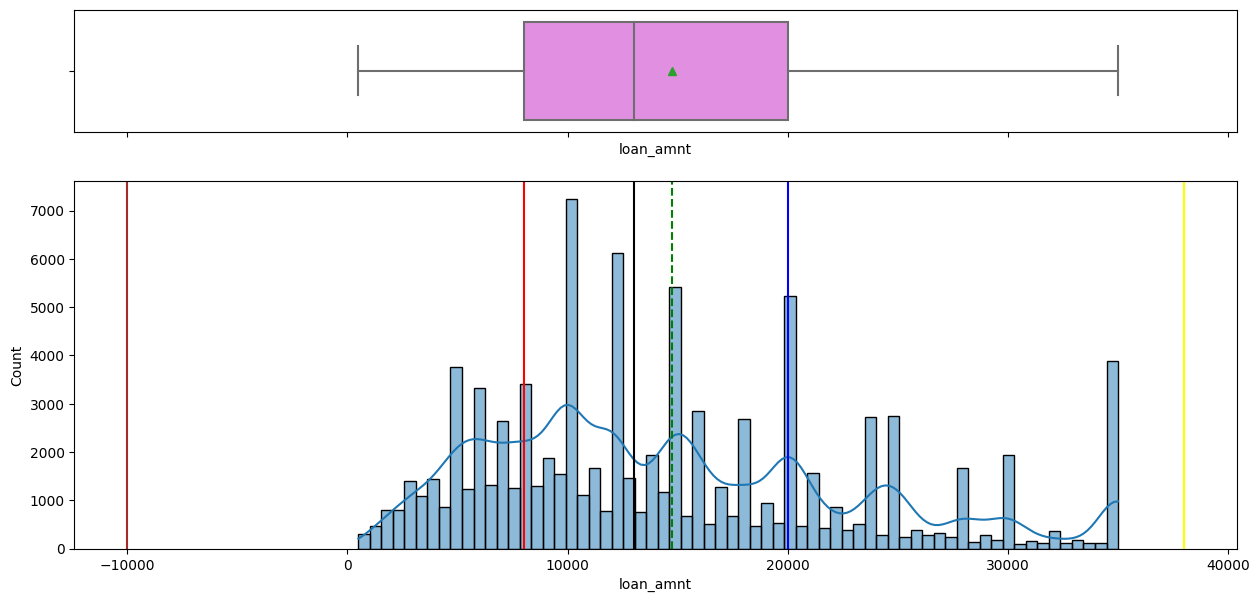

In [177]:
histogram_boxplot(df_train, "loan_amnt", kde=True)

#### interest_rate

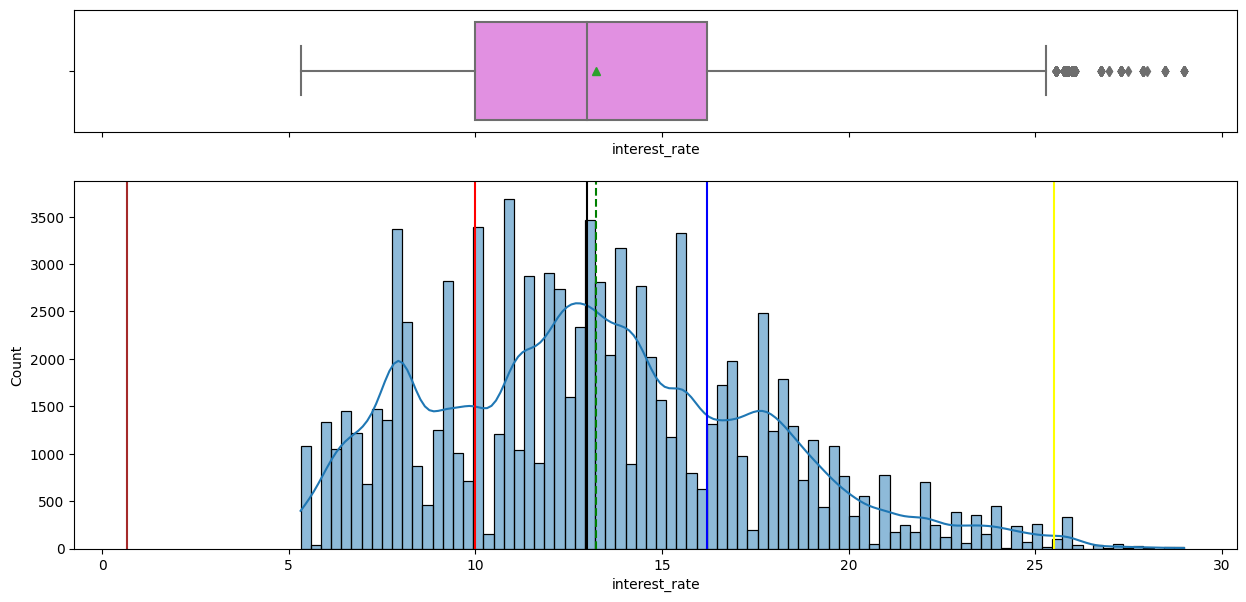

In [178]:
histogram_boxplot(df_train, "interest_rate", kde=True)

#### annual_income

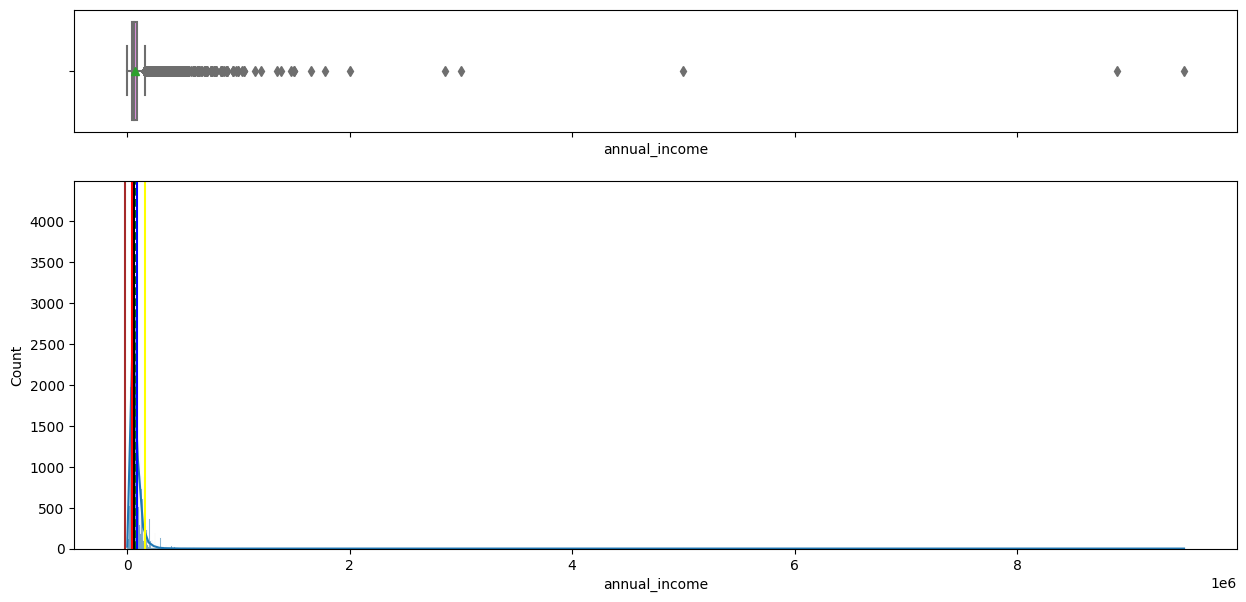

In [179]:
histogram_boxplot(df_train, "annual_income", kde=True)

#### debt_to_income

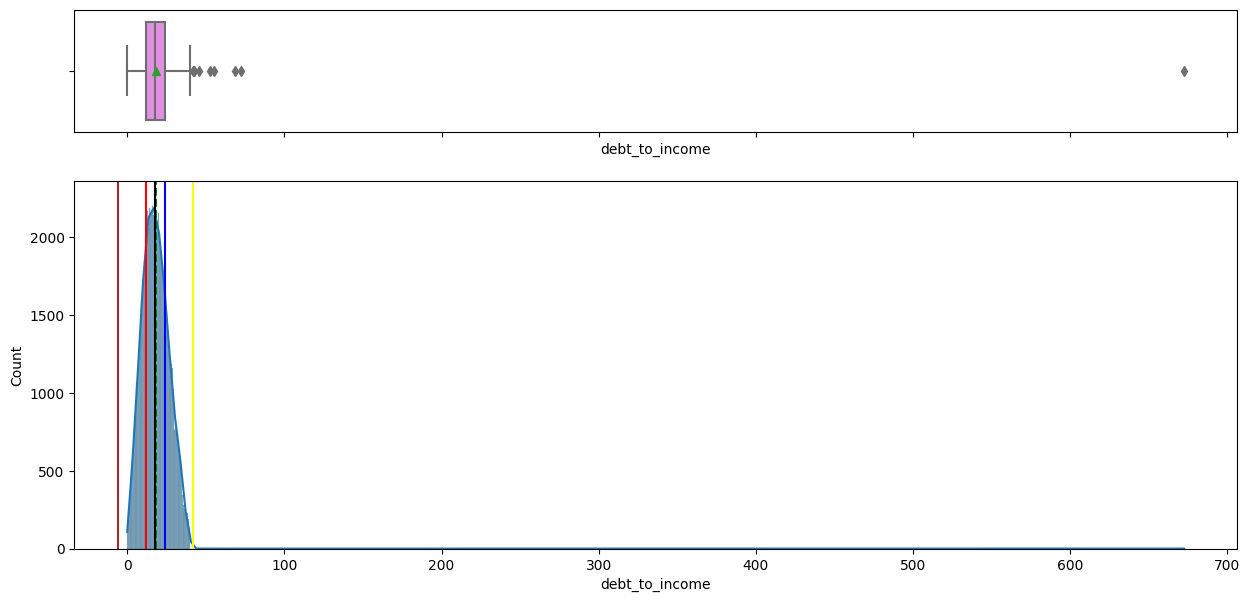

In [180]:
histogram_boxplot(df_train, "debt_to_income", kde=True)

#### delinq_2yrs

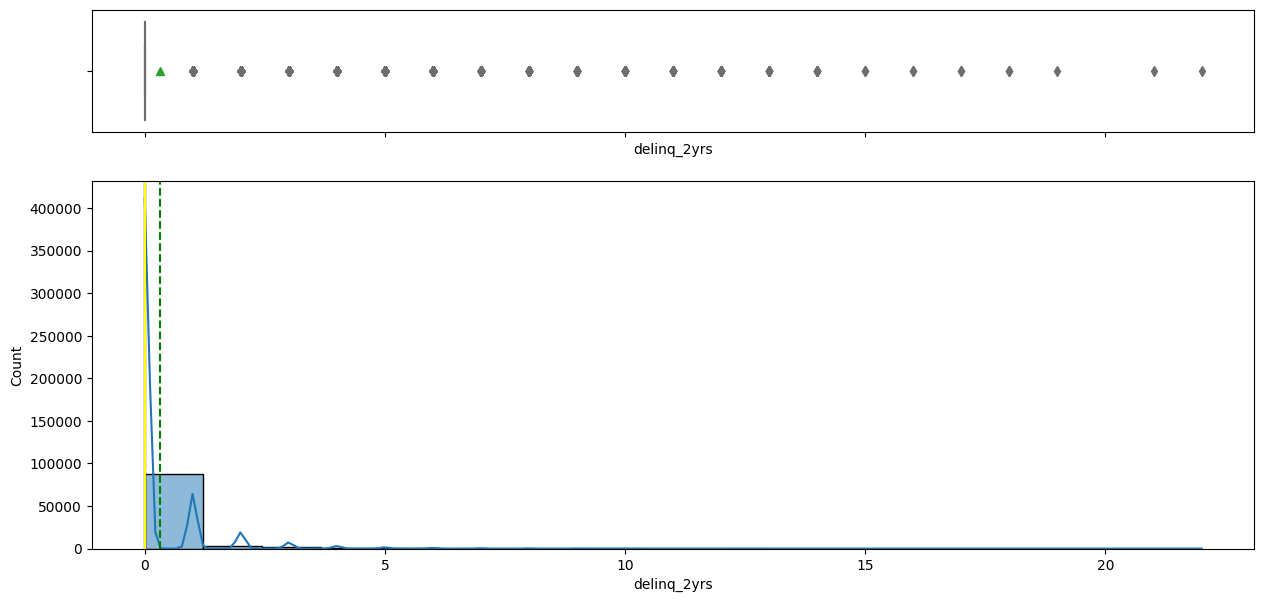

In [181]:
histogram_boxplot(df_train, "delinq_2yrs", kde=True)

#### public_records

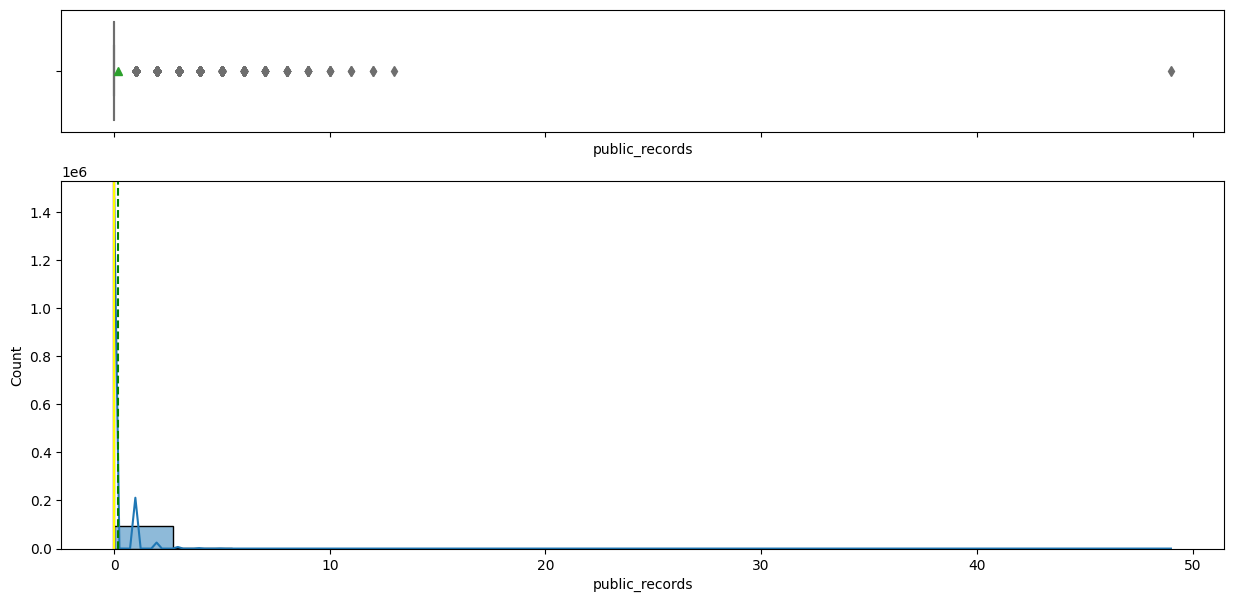

In [182]:
histogram_boxplot(df_train, "public_records", kde=True)

#### revolving_balance

In [183]:
#histogram_boxplot(df_train, "revolving_balance", kde=True)

KeyError: ignored

#### total_acc

In [ ]:
histogram_boxplot(df_train, "total_acc", kde=True)

#### interest_receive

In [ ]:
histogram_boxplot(df_train, "interest_receive", kde=True)

#### last_week_pay

In [ ]:
histogram_boxplot(df_train, "last_week_pay", kde=True)

#### total_current_balance

In [ ]:
histogram_boxplot(df_train, "total_current_balance", kde=True)

#### total_revolving_limit

In [ ]:
histogram_boxplot(df_train, "total_revolving_limit", kde=True)

print('total_revolving_limit mean: ',df_train['total_revolving_limit'].mean())
print('total_revolving_limit median: ',df_train['total_revolving_limit'].median())

#### loan_term

In [ ]:
labeled_barplot(df_train, "loan_term")

#### loan_grade

In [ ]:
labeled_barplot(df_train, "loan_grade")

#### loan_subgrade

In [ ]:
labeled_barplot(df_train, "loan_subgrade")

#### job_experience

In [ ]:
labeled_barplot(df_train, "job_experience")

#### home_ownership

In [ ]:
labeled_barplot(df_train, "home_ownership")

#### income_verification_status

In [ ]:
labeled_barplot(df_train, "income_verification_status")

#### loan_purpose

In [ ]:
labeled_barplot(df_train, "loan_purpose")

#### state_code

In [ ]:
labeled_barplot(df_train, "state_code")

#### application_type

In [ ]:
labeled_barplot(df_train, "application_type")

In [ ]:
labeled_barplot(df_train, "default")

### Bivariate analysis

#### Correlation between columns with heatmap

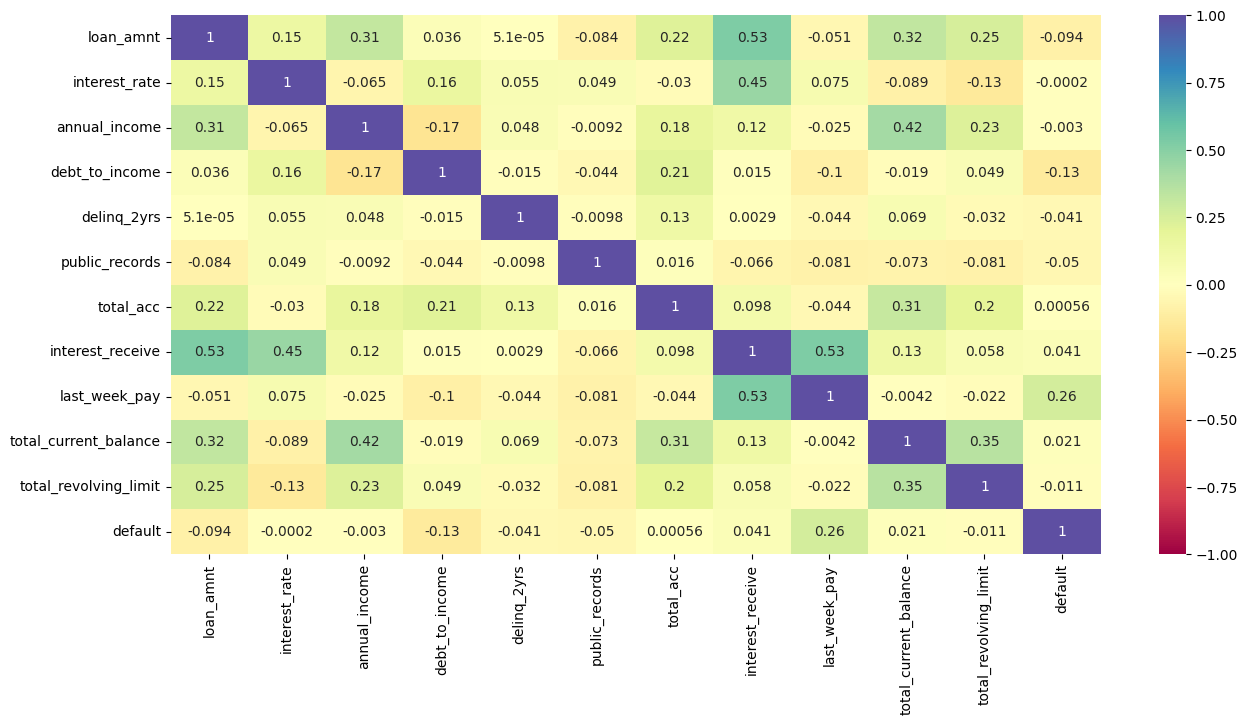

In [293]:
#Let us find the correlation and plot the heatmap
corr = df_train.corr()
plt.figure(figsize=(15, 7))
sns.heatmap(data=df_train.corr(), annot=True, vmin=-1, vmax=1,cmap="Spectral");
plt.show()

In [ ]:
plt.figure(figsize=(20, 15))
#sns.pairplot(data=df_train,hue='default')
#plt.show()

#### Let us look at the relationships between default column and other features


#### default vs loan_amnt

In [ ]:
distribution_plot_wrt_target(df_train, "loan_amnt", "default")

#### default vs interest_rate

In [ ]:
distribution_plot_wrt_target(df_train, "interest_rate", "default")

#### default vs annual_income

In [ ]:
distribution_plot_wrt_target(df_train, "annual_income", "default")

#### default vs debt_to_income

In [ ]:
distribution_plot_wrt_target(df_train, "debt_to_income", "default")

#### default vs delinq_2yrs

In [ ]:
distribution_plot_wrt_target(df_train, "delinq_2yrs", "default")
stacked_barplot(df_train,"delinq_2yrs", "default")

#### default vs public_records

In [ ]:
distribution_plot_wrt_target(df_train, "public_records", "default")
stacked_barplot(df_train,"public_records", "default")

#### default vs revolving_balance

In [ ]:
distribution_plot_wrt_target(df_train, "revolving_balance", "default")

#### default vs total_acc

In [ ]:
distribution_plot_wrt_target(df_train, "total_acc", "default")
stacked_barplot(df_train,"total_acc", "default")

#### default vs interest_receive

In [ ]:
distribution_plot_wrt_target(df_train, "interest_receive", "default")

#### default vs last_week_pay

In [ ]:
distribution_plot_wrt_target(df_train, "last_week_pay", "default")
stacked_barplot(df_train,"last_week_pay", "default")

#### default vs total_current_balance

In [ ]:
distribution_plot_wrt_target(df_train, "total_current_balance", "default")

#### default vs total_revolving_limit

In [ ]:
distribution_plot_wrt_target(df_train, "total_revolving_limit", "default")

#### default vs loan_term

In [ ]:
stacked_barplot(df_train,"loan_term", "default")

#### default vs loan_grade

In [ ]:
stacked_barplot(df_train,"loan_grade", "default")

#### default vs loan_subgrade

In [ ]:
stacked_barplot(df_train,"loan_subgrade", "default")

#### default vs job_experience

In [ ]:
stacked_barplot(df_train,"job_experience", "default")

#### default vs home_ownership

In [ ]:
stacked_barplot(df_train,"home_ownership", "default")

#### default vs income_verification_status

In [ ]:
stacked_barplot(df_train,"income_verification_status", "default")

#### default vs loan_purpose

In [ ]:
stacked_barplot(df_train,"loan_purpose", "default")

#### default vs state_code

In [ ]:
stacked_barplot(df_train,"state_code", "default")

#### default vs application_type

In [ ]:
stacked_barplot(df_train,"application_type", "default")

### Data Processing

#### Missing value treatment

In [626]:
df_train.isna().sum()

loan_amnt                        0
loan_term                        0
interest_rate                    0
loan_grade                       0
loan_subgrade                    0
job_experience                4702
home_ownership                   0
annual_income                    1
income_verification_status       0
loan_purpose                     0
state_code                       0
debt_to_income                   0
delinq_2yrs                      2
public_records                   2
revolving_balance                0
total_acc                        2
interest_receive                 0
application_type                 0
last_week_pay                 1924
total_current_balance         7386
total_revolving_limit         7386
default                          0
dtype: int64

In [627]:
df_train['loan_term'].value_counts()

3 years    65211
5 years    27963
Name: loan_term, dtype: int64

In [628]:
cat_cols = df_train.describe(include=["object"]).columns
cat_cols

Index(['loan_term', 'loan_grade', 'loan_subgrade', 'job_experience',
       'home_ownership', 'income_verification_status', 'loan_purpose',
       'state_code', 'application_type'],
      dtype='object')

In [629]:
for i in cat_cols:
    print(" val count: ",df_train[i].value_counts(dropna=False))
    print("*"*50)

 val count:  3 years    65211
5 years    27963
Name: loan_term, dtype: int64
**************************************************
 val count:  B    26865
C    25787
A    15534
D    14715
E     7378
F     2344
G      551
Name: loan_grade, dtype: int64
**************************************************
 val count:  B3    5879
B4    5879
C2    5479
C1    5443
C3    5270
C4    5182
B2    5169
B5    5095
B1    4843
A5    4723
C5    4413
D1    3716
A4    3631
D2    3239
D3    2759
D4    2717
A3    2450
A1    2377
A2    2353
D5    2284
E1    1924
E2    1736
E3    1513
E4    1228
E5     977
F1     745
F2     545
F3     465
F4     355
F5     234
G1     174
G2     146
G3     105
G5      66
G4      60
Name: loan_subgrade, dtype: int64
**************************************************
 val count:  <5 Years      40610
10+ years     30362
6-10 years    17500
NaN            4702
Name: job_experience, dtype: int64
**************************************************
 val count:  MORTGAGE    46445
RENT   

In [630]:
df_1 = df_train.copy()

In [631]:
# From the above data we can see that there is only 1 data point for state code='ID'.
# The below code gives the row with state_code="ID".
# We can encode the State code to numerical column as shown below:

state_code = {'AK':0,  'AL':1,  'AR':2,  'AZ':3,  'CA':4 , 'CO':5,  'CT':6,  'DC':7,  'DE':8,
              'FL':9,  'GA':10, 'HI':11, 'IA':12, 'ID':13, 'IL':14, 'IN':15, 'KS':16, 'KY':17,
              'LA':18, 'MA':19, 'MD':20, 'ME':21, 'MI':22, 'MN':23, 'MO':24, 'MS':25, 'MT':26,
              'NC':27, 'ND':28, 'NE':29, 'NH':30, 'NJ':31, 'NM':32, 'NV':33, 'NY':34, 'OH':35,
              'OK':36, 'OR':37, 'PA':38, 'RI':39, 'SC':40, 'SD':41, 'TN':42, 'TX':43, 'UT':44,
              'VA':45, 'VT':46, 'WA':47, 'WI':48, 'WV':49, 'WY':50}
df_1['state_code'] = df_1['state_code'].map(state_code).astype('int64')



In [632]:
#Similarly, to avoid having too many column when we do one hot encoding, we can also convert the loan_subgrade into a numerical column as well.
loan_subgrade = {'A1':0,  'A2':1,  'A3':2,  'A4':3,  'A5':4,
                 'B1':5,  'B2':6,  'B3':7,  'B4':8,  'B5':9,
                 'C1':10, 'C2':11, 'C3':12, 'C4':13, 'C5':14,
                 'D1':15, 'D2':16, 'D3':17, 'D4':18, 'D5':19,
                 'E1':20, 'E2':21, 'E3':22, 'E4':23, 'E5':24,
                 'F1':25, 'F2':26, 'F3':27, 'F4':28, 'F5':29,
                 'G1':30, 'G2':31, 'G3':32, 'G4':33, 'G5':34}
df_1['loan_subgrade'] = df_1['loan_subgrade'].map(loan_subgrade).astype('int64')

In [633]:
#Sometimes if there are characters shuch as "<", there could be errors while using XGBoost.
job_experience = { np.NaN:0,'<5 Years':1, '6-10 years':2, '10+ years':3}
df_1['job_experience'] = df_1['job_experience'].map(job_experience).astype('int64')

In [634]:
loan_term = {'3 years': 0, '5 years': 1}
df_1['loan_term'] = df_1['loan_term'].map(loan_term).astype('int64')

loan_grade = {'A':0, 'B':1, 'C':2, 'D':3, 'E':4, 'F':5, 'G':6}
df_1['loan_grade'] = df_1['loan_grade'].map(loan_grade).astype('int64')

home_ownership = {'MORTGAGE':0, 'RENT':1, 'OWN':2, 'OTHER':3, 'NONE':4}
df_1['home_ownership'] = df_1['home_ownership'].map(home_ownership).astype('int64')

income_verification_status = {'Verified':0, 'Not Verified':1, 'Source Verified':2}
df_1['income_verification_status'] = df_1['income_verification_status'].map(income_verification_status).astype('int64')

loan_purpose = {'debt_consolidation': 0, 'credit_card':1, 'home_improvement': 2, 'other': 3}
df_1['loan_purpose'] = df_1['loan_purpose'].map(loan_purpose).astype('int64')

application_type = {'INDIVIDUAL': 0, 'JOINT':1}
df_1['application_type'] = df_1['application_type'].map(application_type).astype('int64')

In [635]:
df_1['job_experience'].value_counts()

1    40610
3    30362
2    17500
0     4702
Name: job_experience, dtype: int64

In [636]:
# Treat the missing values in Numerical columns with missing values
df_1.annual_income.fillna(df_1.annual_income.median(), inplace=True)
df_1.delinq_2yrs.fillna(df_1.delinq_2yrs.median(), inplace=True)
df_1.public_records.fillna(df_1.public_records.median(), inplace=True)
df_1.last_week_pay.fillna(df_1.last_week_pay.median(), inplace=True)
df_1.total_current_balance.fillna(df_1.total_current_balance.median(), inplace=True)
df_1.total_revolving_limit.fillna(df_1.total_revolving_limit.median(), inplace=True)
df_1.total_acc.fillna(df_1.total_acc.median(), inplace=True)

In [637]:
df_1.isna().sum()

loan_amnt                     0
loan_term                     0
interest_rate                 0
loan_grade                    0
loan_subgrade                 0
job_experience                0
home_ownership                0
annual_income                 0
income_verification_status    0
loan_purpose                  0
state_code                    0
debt_to_income                0
delinq_2yrs                   0
public_records                0
revolving_balance             0
total_acc                     0
interest_receive              0
application_type              0
last_week_pay                 0
total_current_balance         0
total_revolving_limit         0
default                       0
dtype: int64

#### Outlier Treatment

In [ ]:
# checking the % outliers
num_cols = df_1.describe(include=["float","int64"]).columns
for i in num_cols:
  lower_range = get_lower_upper(df_1[i], False)
  upper_range = get_lower_upper(df_1[i])
  # checking the % outliers
  perc = (((df_1[i]) < lower_range) | ((df_1[i]) > upper_range)).sum() / len(df_1) * 100
  print(i," lower_range: ",lower_range.round(2)," upper_range: ",upper_range.round(2)," perc: ",perc.round(2),"%")


**Let's find outliers in the data using z-score with a threshold of 3.**

The formula for z-score is:

z = (x-μ) / σ

where, μ is the mean and σ is the standard deviation

For a normal distribution of values of a column, the z-scores must lie in the range of -3 to +3. Any z-score that lies outside of this range can be considered as an outlier. Hence in the below code, we set threshold as 3 to get higher outliers and threshold as -3 to get lower outliers.

In [ ]:
higherthreshold = 3
lowerthreshold = -3
higherout = {}
lowerout = {}
for col in df_1.describe().columns:
    i = df_1[col]
    mean = np.mean(df_1[col])
    std = np.std(df_1[col])
    higherOutliers = []
    lowerOutliers = []
    for v in i:
        z = (v - mean) / std
        if z > higherthreshold:
            higherOutliers.append(v)
        if z < lowerthreshold:
            lowerOutliers.append(v)
    higherOutliers.sort()
    lowerOutliers.sort()
    higherout[i.name] = higherOutliers
    lowerout[i.name] = lowerOutliers

print("The following are the outliers in the data:")
for key, value in higherout.items():
    print("\n Higher Outliers", key, ":", value)
for key, value in lowerout.items():
    print("\n Lower Outliers", key, ":", value)

**After identifying outliers, we can decide whether to remove/treat them or not. It depends on one's approach, here we are not going to treat them as there will be outliers in real case scenario. There might be customers who have higher income, public records, etc., and we would want our model to learn the underlying pattern for such customers.**

### Data Splitting

In [638]:
df_2 = df_1.copy()

In [639]:
# Separate independent and dependent variable in training dataset
X = df_2.drop(["default"], axis=1)
y = df_2["default"]

In [640]:
# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(55904, 21) (18635, 21) (18635, 21)


In [641]:
"""
X_val = pd.concat([X_val, df_state_ID])
X_test = pd.concat([X_test, df_state_ID])
"""
print(X_train.shape, X_val.shape, X_test.shape)


(55904, 21) (18635, 21) (18635, 21)


#### Imputer

In [642]:
# Creating an instance of the SimpleImputer to take care of the missing values.
#imputer = SimpleImputer(strategy="most_frequent")
imputer = KNNImputer(n_neighbors=5)

#Impute the missing values in the columns Education, Marital_Status and the Income_Category columns
# in X_train, X_val and the X_test
null_col=["job_experience"]
# Fit and transform the train data
X_train[null_col] = imputer.fit_transform(X_train[null_col])

# Transform the validation data
X_val[null_col]  =  imputer.fit_transform(X_val[null_col])

# Transform the test data
X_test[null_col] = imputer.fit_transform(X_test[null_col])

In [643]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 55904 entries, 62700 to 29142
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loan_amnt                   55904 non-null  int64  
 1   loan_term                   55904 non-null  int64  
 2   interest_rate               55904 non-null  float64
 3   loan_grade                  55904 non-null  int64  
 4   loan_subgrade               55904 non-null  int64  
 5   job_experience              55904 non-null  float64
 6   home_ownership              55904 non-null  int64  
 7   annual_income               55904 non-null  float64
 8   income_verification_status  55904 non-null  int64  
 9   loan_purpose                55904 non-null  int64  
 10  state_code                  55904 non-null  int64  
 11  debt_to_income              55904 non-null  float64
 12  delinq_2yrs                 55904 non-null  float64
 13  public_records             

In [644]:
cols = X_train.select_dtypes(include=["object"])

#Now convert these columns to type category
X_train[cols.columns] = (X_train[cols.columns]).astype("category")
X_train.info()
"""
for i in X_train[cols]:
    print(X_train[i].value_counts())
    print("*" * 30)
"""

<class 'pandas.core.frame.DataFrame'>
Int64Index: 55904 entries, 62700 to 29142
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loan_amnt                   55904 non-null  int64  
 1   loan_term                   55904 non-null  int64  
 2   interest_rate               55904 non-null  float64
 3   loan_grade                  55904 non-null  int64  
 4   loan_subgrade               55904 non-null  int64  
 5   job_experience              55904 non-null  float64
 6   home_ownership              55904 non-null  int64  
 7   annual_income               55904 non-null  float64
 8   income_verification_status  55904 non-null  int64  
 9   loan_purpose                55904 non-null  int64  
 10  state_code                  55904 non-null  int64  
 11  debt_to_income              55904 non-null  float64
 12  delinq_2yrs                 55904 non-null  float64
 13  public_records             

'\nfor i in X_train[cols]:\n    print(X_train[i].value_counts())\n    print("*" * 30)\n'

In [645]:
cols = X_val.select_dtypes(include=["object"])

#Now convert these columns to type category
X_val[cols.columns] = (X_val[cols.columns]).astype("category")
for i in cols.columns:
    print(X_val[i].value_counts())
    print("*" * 30)
X_val.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18635 entries, 90284 to 73528
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loan_amnt                   18635 non-null  int64  
 1   loan_term                   18635 non-null  int64  
 2   interest_rate               18635 non-null  float64
 3   loan_grade                  18635 non-null  int64  
 4   loan_subgrade               18635 non-null  int64  
 5   job_experience              18635 non-null  float64
 6   home_ownership              18635 non-null  int64  
 7   annual_income               18635 non-null  float64
 8   income_verification_status  18635 non-null  int64  
 9   loan_purpose                18635 non-null  int64  
 10  state_code                  18635 non-null  int64  
 11  debt_to_income              18635 non-null  float64
 12  delinq_2yrs                 18635 non-null  float64
 13  public_records             

In [646]:
cols = X_test.select_dtypes(include=["object", "category"])

#Now convert these columns to type category
X_test[cols.columns] = (X_test[cols.columns]).astype("category")
for i in cols.columns:
    print(X_test[i].value_counts())
    print("*" * 30)
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18635 entries, 89829 to 34251
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loan_amnt                   18635 non-null  int64  
 1   loan_term                   18635 non-null  int64  
 2   interest_rate               18635 non-null  float64
 3   loan_grade                  18635 non-null  int64  
 4   loan_subgrade               18635 non-null  int64  
 5   job_experience              18635 non-null  float64
 6   home_ownership              18635 non-null  int64  
 7   annual_income               18635 non-null  float64
 8   income_verification_status  18635 non-null  int64  
 9   loan_purpose                18635 non-null  int64  
 10  state_code                  18635 non-null  int64  
 11  debt_to_income              18635 non-null  float64
 12  delinq_2yrs                 18635 non-null  float64
 13  public_records             

#### Encoding categorical variables

In [647]:

## code to impute missing values in X_train
X_train = pd.get_dummies(X_train, drop_first=True)
## code to impute missing values in X_val
X_val = pd.get_dummies(X_val, drop_first=True)
## code to impute missing values in X_test
X_test = pd.get_dummies(X_test, drop_first=True)

print("X_train shape: ",X_train.shape," X_val shape: ",X_val.shape," X_test shape: ",X_test.shape)


X_train shape:  (55904, 21)  X_val shape:  (18635, 21)  X_test shape:  (18635, 21)


In [648]:
for cols in X_train.columns:
  print(cols)
#X_train.info()

loan_amnt
loan_term
interest_rate
loan_grade
loan_subgrade
job_experience
home_ownership
annual_income
income_verification_status
loan_purpose
state_code
debt_to_income
delinq_2yrs
public_records
revolving_balance
total_acc
interest_receive
application_type
last_week_pay
total_current_balance
total_revolving_limit


In [649]:
for cols in X_val.columns:
  print(cols)
#X_val.info()

loan_amnt
loan_term
interest_rate
loan_grade
loan_subgrade
job_experience
home_ownership
annual_income
income_verification_status
loan_purpose
state_code
debt_to_income
delinq_2yrs
public_records
revolving_balance
total_acc
interest_receive
application_type
last_week_pay
total_current_balance
total_revolving_limit


In [650]:
#for cols in X_test.columns:
  #print(cols)
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18635 entries, 89829 to 34251
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loan_amnt                   18635 non-null  int64  
 1   loan_term                   18635 non-null  int64  
 2   interest_rate               18635 non-null  float64
 3   loan_grade                  18635 non-null  int64  
 4   loan_subgrade               18635 non-null  int64  
 5   job_experience              18635 non-null  float64
 6   home_ownership              18635 non-null  int64  
 7   annual_income               18635 non-null  float64
 8   income_verification_status  18635 non-null  int64  
 9   loan_purpose                18635 non-null  int64  
 10  state_code                  18635 non-null  int64  
 11  debt_to_income              18635 non-null  float64
 12  delinq_2yrs                 18635 non-null  float64
 13  public_records             

## Model Building

**Let's define a function to output different metrics (including accuracy) on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [651]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1

        },
        index=[0],
    )

    return df_perf

### Model Building with original data

Sample code for model building with original data

In [587]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("GradientBoosting", GradientBoostingClassifier(random_state=1)))
models.append(("Decisiontree", DecisionTreeClassifier(random_state=1)))
models.append(("XGB", XGBClassifier(random_state=1, eval_metric='logloss')))


results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []

# loop through all models to get the mean cross validated score
print("\n" "Training Performance:" "\n")
for name, model in models:
    print('name: ',name," model: ",model)
    model.fit(X_train, y_train)
    #scores = recall_score(y_train, model.predict(X_train))
    scores = accuracy_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train)
    #scores_val = recall_score(y_val, model.predict(X_val))
    scores_val = accuracy_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

name:  Bagging  model:  BaggingClassifier(random_state=1)
Bagging: 0.9869597882083572
name:  Random forest  model:  RandomForestClassifier(random_state=1)
Random forest: 0.9999821121923297
name:  Adaboost  model:  AdaBoostClassifier(random_state=1)
Adaboost: 0.8189217229536349
name:  GradientBoosting  model:  GradientBoostingClassifier(random_state=1)
GradientBoosting: 0.827633085289067
name:  Decisiontree  model:  DecisionTreeClassifier(random_state=1)
Decisiontree: 1.0
name:  XGB  model:  XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              m

In [588]:
print("\nTraining and Validation Performance Difference for original data:\n")

for name, model in models:
    model.fit(X_train, y_train)
    #scores_train = recall_score(y_train, model.predict(X_train))
    #scores_val = recall_score(y_val, model.predict(X_val))
    scores_train = accuracy_score(y_train, model.predict(X_train))
    scores_val = accuracy_score(y_val, model.predict(X_val))
    difference = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference))


Training and Validation Performance Difference for original data:

Bagging: Training Score: 0.9870, Validation Score: 0.8522, Difference: 0.1348
Random forest: Training Score: 1.0000, Validation Score: 0.8313, Difference: 0.1687
Adaboost: Training Score: 0.8189, Validation Score: 0.8196, Difference: -0.0007
GradientBoosting: Training Score: 0.8276, Validation Score: 0.8262, Difference: 0.0014
Decisiontree: Training Score: 1.0000, Validation Score: 0.7926, Difference: 0.2074
XGB: Training Score: 0.9055, Validation Score: 0.8713, Difference: 0.0342


### Model Building with Oversampled data

In [28]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

NameError: ignored

Sample code for model building with oversampled data

In [103]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("GradientBoosting", GradientBoostingClassifier(random_state=1)))
models.append(("XGB", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("Decisiontree", DecisionTreeClassifier(random_state=1)))


results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []

# loop through all models to get the mean cross validated score
print("\n" "Training Performance for oversampled data:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    #scores = recall_score(y_train_over, model.predict(X_train_over))
    scores = accuracy_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance for oversampled data:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    #scores_val = recall_score(y_val, model.predict(X_val))
    scores_val = accuracy_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance for oversampled data:

Bagging: 0.9912027588148357
Random forest: 1.0
Adaboost: 0.8315504257864733
GradientBoosting: 0.8600065686067516
XGB: 0.9341497173153166
Decisiontree: 1.0

Validation Performance for oversampled data:

Bagging: 0.8370807620069761
Random forest: 0.8232358465253555
Adaboost: 0.7584115910920312
GradientBoosting: 0.798121813791253
XGB: 0.8684196404614972
Decisiontree: 0.7788569895358197


In [104]:
print("\nTraining and Validation Performance Difference for oversampled data:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    #scores_train = recall_score(y_train_over, model.predict(X_train_over))
    #scores_val = recall_score(y_val, model.predict(X_val))
    scores_train = accuracy_score(y_train_over, model.predict(X_train_over))
    scores_val = accuracy_score(y_val, model.predict(X_val))
    difference_ov = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference_ov))


Training and Validation Performance Difference for oversampled data:

Bagging: Training Score: 0.9912, Validation Score: 0.8371, Difference: 0.1541
Random forest: Training Score: 1.0000, Validation Score: 0.8232, Difference: 0.1768
Adaboost: Training Score: 0.8316, Validation Score: 0.7584, Difference: 0.0731
GradientBoosting: Training Score: 0.8600, Validation Score: 0.7981, Difference: 0.0619
XGB: Training Score: 0.9341, Validation Score: 0.8684, Difference: 0.0657
Decisiontree: Training Score: 1.0000, Validation Score: 0.7789, Difference: 0.2211


### Model Building with Undersampled data

In [498]:
print("Before Undersampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Undersampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

# Random undersampler for under sampling the data
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

print("After Undersampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Undersampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))


print("After Undersampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Undersampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Undersampling, counts of label 'Yes': 13277
Before Undersampling, counts of label 'No': 42627 

After Undersampling, counts of label 'Yes': 13277
After Undersampling, counts of label 'No': 13277 

After Undersampling, the shape of train_X: (26554, 22)
After Undersampling, the shape of train_y: (26554,) 



Sample code for model building with undersampled data

In [106]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("GradientBoosting", GradientBoostingClassifier(random_state=1)))
models.append(("XGB", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("Decisiontree", DecisionTreeClassifier(random_state=1)))


results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []

# loop through all models to get the mean cross validated score
print("\n" "Training Performance for undersampled data:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    #scores = recall_score(y_train_un, model.predict(X_train_un))
    scores = accuracy_score(y_train_un, model.predict(X_train_un))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance for undersampled data:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    #scores_val = recall_score(y_val, model.predict(X_val))
    scores_val = accuracy_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance for undersampled data:

Bagging: 0.986066129396701
Random forest: 1.0
Adaboost: 0.7083301950741885
GradientBoosting: 0.7578519243805076
XGB: 0.9075092264818859
Decisiontree: 1.0

Validation Performance for undersampled data:

Bagging: 0.8022538234504963
Random forest: 0.7595385028172793
Adaboost: 0.7227797155889455
GradientBoosting: 0.763026562919238
XGB: 0.8434665951167158
Decisiontree: 0.7096860745908237


In [107]:
print("\nTraining and Validation Performance Difference for undersampled data:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    #scores_train = recall_score(y_train_un, model.predict(X_train_un))
    #scores_val = recall_score(y_val, model.predict(X_val))
    scores_train = accuracy_score(y_train_un, model.predict(X_train_un))
    scores_val = accuracy_score(y_val, model.predict(X_val))
    difference_un = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference_un))


Training and Validation Performance Difference for undersampled data:

Bagging: Training Score: 0.9861, Validation Score: 0.8023, Difference: 0.1838
Random forest: Training Score: 1.0000, Validation Score: 0.7595, Difference: 0.2405
Adaboost: Training Score: 0.7083, Validation Score: 0.7228, Difference: -0.0144
GradientBoosting: Training Score: 0.7579, Validation Score: 0.7630, Difference: -0.0052
XGB: Training Score: 0.9075, Validation Score: 0.8435, Difference: 0.0640
Decisiontree: Training Score: 1.0000, Validation Score: 0.7097, Difference: 0.2903


### HyperparameterTuning

In [107]:
# defining kfold
kfold = KFold(n_splits=10, random_state=1, shuffle = True)

##XGBoosting

#### Sample tuning method for XGBoost with original data

In [379]:
# defining model
Model = XGBClassifier(random_state=1, eval_metric="logloss")

# Parameter grid to pass in RandomSearchCV
"""
param_grid={
   'n_estimators':np.arange(50,300,50),
   'scale_pos_weight':[0,1,2,5,10],
   'learning_rate':[0.01,0.1,0.2,0.05],
   'gamma':[0,1,3,5],
   'subsample':[0.7,0.8,0.9,1]
}

param_grid={
   'n_estimators':np.arange(50,300,50),
   'scale_pos_weight':[0,1,2,3,4,5,10],
   'learning_rate':[0.01,0.1,0.2,0.3,0.4,0.5,0.05],
   'gamma':[0,1,3,4,5],
   'subsample':[0.7,0.8,0.9,1]
}
"""

param_grid={
   'n_estimators':np.arange(100,1000,50),
   'eval_metric':['logloss','auc','error'],
   'eta':[0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5],
   'scale_pos_weight':[0,1,2,3,4,5,6,7,10],
   'learning_rate':[0.01,0.05,0.1,0.15,0.2,0.25,0.3,0.4,0.5],
   'max_depth':[3,4,5,6,7,8,9,10],
   'min_child_weight':[1,2,3,4,5,6,7],
   'gamma':[0,0.1,0.2,0.5,1,1.5,2,2.5,3,3.5,4,4.5,5],
   'colsample_bytree':[0.3,0.4,0.5,0.7,0.8,0.9,1],
   'subsample':[0.5,0.6,0.7,0.8,0.9,1]
}

# Type of scoring used to compare parameter combinations
#scorer = metrics.make_scorer(metrics.recall_score)
scorer = metrics.make_scorer(metrics.accuracy_score)

#Calling RandomizedSearchCV
#randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=30, n_jobs = -1, scoring=scorer, cv=5, random_state=1)
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=5, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.6, 'scale_pos_weight': 3, 'n_estimators': 350, 'min_child_weight': 4, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 1.5, 'eval_metric': 'error', 'eta': 0.15, 'colsample_bytree': 0.7} with CV score=0.8727640680370914:


In [655]:
#Build and Fit the model tuned_xgb_orig with original training data with the above best parameters
"""
{'colsample_bytree': 0.6655392754230048, 'gamma': 4.198875359789924, 'max_depth': 17.0, 'min_child_weight': 1.0, 'reg_alpha': 57.0, 'reg_lambda': 0.896332305739873}

tuned_xgb_orig = XGBClassifier(
    random_state=1,
    eval_metric="logloss",
    subsample=0.7,
    scale_pos_weight=2,
    n_estimators=150,
    min_child_weight= 5,
    learning_rate= 0.25,
    gamma=5,
)
tuned_xgb_orig.fit(X_train, y_train)

"""
""" Highest so far """

tuned_xgb_orig = XGBClassifier(
    eval_metric="logloss",
    subsample=0.7,
    eta=0.2,
    scale_pos_weight=2,
    n_estimators=150,
    min_child_weight= 1,
    max_depth=6,
    learning_rate= 0.25,
    gamma=5,
    colsample_bytree=0.7
)
tuned_xgb_orig.fit(X_train, y_train)


"""
tuned_xgb_orig = XGBClassifier(
    eval_metric="logloss",
    learning_rate =0.1,
    n_estimators=1000,
    max_depth=5,
    min_child_weight=1,
    gamma=0,
    subsample=0.8,
    colsample_bytree=0.8,
    objective= 'binary:logistic',
    nthread=4,
    scale_pos_weight=1,
    seed=27
)
tuned_xgb_orig.fit(X_train, y_train)
"""
"""
Best parameters are {'subsample': 0.6, 'scale_pos_weight': 3, 'n_estimators': 350, 'min_child_weight': 4, 'max_depth': 8,
 'learning_rate': 0.1, 'gamma': 1.5, 'eval_metric': 'error', 'eta': 0.15, 'colsample_bytree': 0.7} with CV score=0.8717980909026766:

tuned_xgb_orig = XGBClassifier(
    random_state=1,
    eval_metric="error",
    eta=0.15,
    learning_rate =0.1,
    n_estimators=350,
    max_depth=8,
    min_child_weight=4,
    gamma=1.5,
    subsample=0.6,
    colsample_bytree=0.7,
    objective= 'binary:logistic',
    scale_pos_weight=3
)
tuned_xgb_orig.fit(X_train, y_train)

Best parameters are {'subsample': 0.6, 'scale_pos_weight': 3, 'n_estimators': 350,
 'min_child_weight': 4, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 1.5, 'eval_metric': 'error', 'eta': 0.15, 'colsample_bytree': 0.7} with CV score=0.8725136464091667:

tuned_xgb_orig = XGBClassifier(
    random_state=1,
    eval_metric="error",
    subsample=0.6,
    eta=0.15,
    scale_pos_weight=3,
    n_estimators=350,
    min_child_weight= 4,
    max_depth=8,
    learning_rate= 0.1,
    gamma=1.5,
    colsample_bytree=0.7
)
tuned_xgb_orig.fit(X_train, y_train)
Best parameters are {'subsample': 0.6, 'scale_pos_weight': 3, 'n_estimators': 350, 'min_child_weight': 4, 'max_depth': 8, 'learning_rate': 0.1,
 'gamma': 1.5, 'eval_metric': 'error', 'eta': 0.15, 'colsample_bytree': 0.7} with CV score=0.8727640680370914:


tuned_xgb_orig = XGBClassifier(
    random_state=1,
    eval_metric="error",
    subsample=0.6,
    eta=0.15,
    scale_pos_weight=3,
    n_estimators=350,
    min_child_weight= 4,
    max_depth=8,
    learning_rate= 0.1,
    gamma=1.5,
    colsample_bytree=0.7
)
tuned_xgb_orig.fit(X_train, y_train)
"""

'\nBest parameters are {\'subsample\': 0.6, \'scale_pos_weight\': 3, \'n_estimators\': 350, \'min_child_weight\': 4, \'max_depth\': 8,\n \'learning_rate\': 0.1, \'gamma\': 1.5, \'eval_metric\': \'error\', \'eta\': 0.15, \'colsample_bytree\': 0.7} with CV score=0.8717980909026766:\n\ntuned_xgb_orig = XGBClassifier(\n    random_state=1,\n    eval_metric="error",\n    eta=0.15,\n    learning_rate =0.1,\n    n_estimators=350,\n    max_depth=8,\n    min_child_weight=4,\n    gamma=1.5,\n    subsample=0.6,\n    colsample_bytree=0.7,\n    objective= \'binary:logistic\',\n    scale_pos_weight=3\n)\ntuned_xgb_orig.fit(X_train, y_train)\n\nBest parameters are {\'subsample\': 0.6, \'scale_pos_weight\': 3, \'n_estimators\': 350,\n \'min_child_weight\': 4, \'max_depth\': 8, \'learning_rate\': 0.1, \'gamma\': 1.5, \'eval_metric\': \'error\', \'eta\': 0.15, \'colsample_bytree\': 0.7} with CV score=0.8725136464091667:\n\ntuned_xgb_orig = XGBClassifier(\n    random_state=1,\n    eval_metric="error",\n  

In [656]:
# Checking performance of the model tuned_xgb_orig on training set
xgb_train_orig = model_performance_classification_sklearn(
    tuned_xgb_orig, X_train, y_train
)
xgb_train_orig

,Accuracy,Recall,Precision,F1
0,0.916,0.809,0.833,0.821


In [657]:
# Checking performance of the model tuned_xgb_orig on validation set
xgb_train_val = model_performance_classification_sklearn(tuned_xgb_orig, X_val, y_val)
xgb_train_val

,Accuracy,Recall,Precision,F1
0,0.872,0.696,0.748,0.721


#### Sample tuning method for XGBoost with oversampled data

In [ ]:
# defining model
Model = XGBClassifier(random_state=1, eval_metric="logloss")

# Parameter grid to pass in RandomSearchCV
"""
param_grid={
   'n_estimators':np.arange(50,300,50),
   'scale_pos_weight':[0,1,2,5,10],
   'learning_rate':[0.01,0.1,0.2,0.05],
   'gamma':[0,1,3,5],
   'subsample':[0.7,0.8,0.9,1]
}
"""
param_grid={
   'n_estimators':np.arange(50,300,50),
   'scale_pos_weight':[0,1,2,3,4,5,10],
   'learning_rate':[0.01,0.1,0.2,0.3,0.4,0.5,0.05],
   'gamma':[0,1,3,4,5],
   'subsample':[0.7,0.8,0.9,1]
}

# Type of scoring used to compare parameter combinations
#scorer = metrics.make_scorer(metrics.recall_score)
scorer = metrics.make_scorer(metrics.accuracy_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=30, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.8, 'scale_pos_weight': 2, 'n_estimators': 200, 'learning_rate': 0.2, 'gamma': 1} with CV score=0.8957005471424264:


In [223]:
#Build and Fit the model tuned_xgb_orig with oversampled training data with the above best parameters
tuned_xgb_over = XGBClassifier(
    random_state=1,
    eval_metric="logloss",
    subsample=0.9,
    scale_pos_weight=2,
    n_estimators=200,
    learning_rate=0.25,
    gamma=5,
)
tuned_xgb_over.fit(X_train_over, y_train_over)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=5, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.25, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, predictor=None, random_state=1, ...)

In [224]:
# Checking performance of the model tuned_xgb_over on oversampled training set
xgb_train_over = model_performance_classification_sklearn(
    tuned_xgb_over, X_train_over, y_train_over
)
xgb_train_over

,Accuracy,Recall,Precision,F1
0,0.949,0.953,0.946,0.949


In [225]:
# Checking performance of the model tuned_xgb_over on validation set
xgb_val_over = model_performance_classification_sklearn(tuned_xgb_over, X_val, y_val)
xgb_val_over

,Accuracy,Recall,Precision,F1
0,0.869,0.714,0.729,0.721


#### Sample tuning method for XGBoost with undersampled data

In [ ]:
# defining model
Model = XGBClassifier(random_state=1, eval_metric="logloss")

# Parameter grid to pass in RandomSearchCV
"""
param_grid={
   'n_estimators':np.arange(50,300,50),
   'scale_pos_weight':[0,1,2,5,10],
   'learning_rate':[0.01,0.1,0.2,0.05],
   'gamma':[0,1,3,5],
   'subsample':[0.7,0.8,0.9,1]
}
"""
param_grid={
   'n_estimators':np.arange(50,300,50),
   'scale_pos_weight':[0,1,2,3,4,5,10],
   'learning_rate':[0.01,0.1,0.2,0.3,0.4,0.5,0.05],
   'gamma':[0,1,3,4,5],
   'subsample':[0.7,0.8,0.9,1]
}
# Type of scoring used to compare parameter combinations
#scorer = metrics.make_scorer(metrics.recall_score)
scorer = metrics.make_scorer(metrics.accuracy_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=30, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 1, 'scale_pos_weight': 1, 'n_estimators': 150, 'learning_rate': 0.2, 'gamma': 5} with CV score=0.8205547807715996:


In [ ]:
#Build and Fit the model tuned_xgb_orig with undersampled training data with the above best parameters
tuned_xgb_un = XGBClassifier(
    random_state=1,
    eval_metric="logloss",
    subsample=1,
    scale_pos_weight=1,
    n_estimators=150,
    learning_rate=0.2,
    gamma=5,
)
tuned_xgb_un.fit(X_train_un, y_train_un)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=5, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, predictor=None, random_state=1, ...)

In [ ]:
# Checking performance of the model tuned_xgb_un on undersampled training set
xgb_train_un = model_performance_classification_sklearn(
    tuned_xgb_un, X_train_un, y_train_un
)
xgb_train_un

,Accuracy,Recall,Precision,F1
0,0.863,0.823,0.893,0.857


In [ ]:
# Checking performance of the model tuned_xgb_un on validation set
xgb_val_un = model_performance_classification_sklearn(tuned_xgb_un, X_val, y_val)
xgb_val_un

,Accuracy,Recall,Precision,F1
0,0.845,0.774,0.644,0.703


##AdaBoost

#### Sample tuning method for AdaBoost with original data

In [ ]:
# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
     "n_estimators": np.arange(10, 110, 10),
     "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
     "base_estimator": [
         DecisionTreeClassifier(max_depth=1, random_state=1),
         DecisionTreeClassifier(max_depth=2, random_state=1),
         DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

# Type of scoring used to compare parameter combinations
#scorer = metrics.make_scorer(metrics.recall_score)
scorer = metrics.make_scorer(metrics.accuracy_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=30, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 70, 'learning_rate': 1, 'base_estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.8560032184678231:


In [594]:
#Build and Fit the model tuned_adab_orig with original training data with the above best parameters
tuned_adab_orig = AdaBoostClassifier(
    random_state=1,
    n_estimators=70,
    learning_rate=1,
    base_estimator=DecisionTreeClassifier(max_depth=3, random_state=1),
)
tuned_adab_orig.fit(X_train, y_train)

AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=3,
                                                         random_state=1),
                   learning_rate=1, n_estimators=70, random_state=1)

In [595]:
# Checking performance of the model tuned_adab_orig on training set
adab_train_orig = model_performance_classification_sklearn(
    tuned_adab_orig, X_train, y_train
)
adab_train_orig

,Accuracy,Recall,Precision,F1
0,0.868,0.558,0.833,0.668


In [596]:
# Checking performance of the model tuned_adab_orig on validation set
adab_train_val = model_performance_classification_sklearn(tuned_adab_orig, X_val, y_val)
adab_train_val

,Accuracy,Recall,Precision,F1
0,0.853,0.518,0.791,0.626


#### Sample tuning method for AdaBoost with oversampled data

In [ ]:
# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
     "n_estimators": np.arange(10, 110, 10),
     "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
     "base_estimator": [
         DecisionTreeClassifier(max_depth=1, random_state=1),
         DecisionTreeClassifier(max_depth=2, random_state=1),
         DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

# Type of scoring used to compare parameter combinations
#scorer = metrics.make_scorer(metrics.recall_score)
scorer = metrics.make_scorer(metrics.accuracy_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=30, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 70, 'learning_rate': 1, 'base_estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.8850854282073565:


In [598]:
#Build and Fit the model tuned_adab_over with original training data with the above best parameters
tuned_adab_over= AdaBoostClassifier(
    random_state=1,
    n_estimators=70,
    learning_rate=1,
    base_estimator=DecisionTreeClassifier(max_depth=3, random_state=1),
)
tuned_adab_over.fit(X_train_over, y_train_over)

NameError: ignored

In [597]:
# Checking performance of the model tuned_adab_over on training set
adab_train_over = model_performance_classification_sklearn(
    tuned_adab_over, X_train_over, y_train_over
)
adab_train_over

NameError: ignored

In [27]:
# Checking performance of the model tuned_adab_over on validation set
adab_val_over = model_performance_classification_sklearn(tuned_adab_over, X_val, y_val)
adab_val_over

NameError: ignored

#### Sample tuning method for AdaBoost with undersampled data

In [ ]:
# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
     "n_estimators": np.arange(10, 110, 10),
     "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
     "base_estimator": [
         DecisionTreeClassifier(max_depth=1, random_state=1),
         DecisionTreeClassifier(max_depth=2, random_state=1),
         DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

# Type of scoring used to compare parameter combinations
#scorer = metrics.make_scorer(metrics.recall_score)
scorer = metrics.make_scorer(metrics.accuracy_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=30, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 100, 'learning_rate': 1, 'base_estimator': DecisionTreeClassifier(max_depth=2, random_state=1)} with CV score=0.7977704519029367:


In [179]:
#Build and Fit the model tuned_adab_un with oundersampled original training data with the above best parameters

tuned_adab_un= AdaBoostClassifier(
    random_state=1,
    n_estimators=100,
    learning_rate=1,
    base_estimator=DecisionTreeClassifier(max_depth=2, random_state=1),
)
tuned_adab_un.fit(X_train_un, y_train_un)

AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=2,
                                                         random_state=1),
                   learning_rate=1, n_estimators=100, random_state=1)

In [180]:
# Checking performance of the model tuned_adab_over on training set
adab_train_un = model_performance_classification_sklearn(
    tuned_adab_un, X_train_un, y_train_un
)
adab_train_un

,Accuracy,Recall,Precision,F1
0,0.817,0.780,0.843,0.810


In [181]:
# Checking performance of the model tuned_adab_un on validation set
adab_val_un = model_performance_classification_sklearn(tuned_adab_un, X_val, y_val)
adab_val_un

,Accuracy,Recall,Precision,F1
0,0.815,0.759,0.585,0.661


##GradientBoosting

#### Sample tuning method for Gradient Boosting with original data

In [589]:
# defining model
Model = GradientBoostingClassifier(random_state=1)

"""
# Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(75,150,25),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "subsample":[0.5,0.7,1],
    "max_features":[0.5,0.7,1],
}
"""
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,200,25),
    "learning_rate": [0.01,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,1],
    "subsample":[0.3,0.4,0.5,0.6,0.7,0.8,1],
    "max_features":[0.3,0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
#scorer = metrics.make_scorer(metrics.recall_score)
scorer = metrics.make_scorer(metrics.accuracy_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=30, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.8, 'n_estimators': 175, 'max_features': 0.7, 'learning_rate': 0.35, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.8600458178877757:


In [599]:
#Build and Fit the model tuned_gb_orig with original training data with the above best parameters
tuned_gb_orig = GradientBoostingClassifier(
    random_state=1,
    subsample=0.8,
    n_estimators=175,
    max_features=0.7,
    learning_rate=0.35,
    init=AdaBoostClassifier(random_state=1)
)
tuned_gb_orig.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.35, max_features=0.7,
                           n_estimators=175, random_state=1, subsample=0.8)

In [600]:
# Checking performance of the model tuned_gb_orig on training set
gb_train_orig = model_performance_classification_sklearn(
    tuned_gb_orig, X_train, y_train
)
gb_train_orig

,Accuracy,Recall,Precision,F1
0,0.871,0.556,0.850,0.672


In [601]:
# Checking performance of the model tuned_gb_orig on validation set
gb_val_orig = model_performance_classification_sklearn(tuned_gb_orig, X_val, y_val)
gb_val_orig

,Accuracy,Recall,Precision,F1
0,0.856,0.519,0.808,0.632


#### Sample tuning method for Gradient Boosting with oversampled data

In [ ]:
# defining model
Model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(75,150,25),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "subsample":[0.5,0.7,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
#scorer = metrics.make_scorer(metrics.recall_score)
scorer = metrics.make_scorer(metrics.accuracy_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=30, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': 125, 'max_features': 0.7, 'learning_rate': 0.2, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.8695789443812775:


In [ ]:
#Build and Fit the model tuned_gb_over with oversampled training data with the above best parameters
tuned_gb_over = GradientBoostingClassifier(
    random_state=1,
    subsample=0.7,
    n_estimators=125,
    max_features=0.7,
    learning_rate=0.2,
    init=AdaBoostClassifier(random_state=1)
)
tuned_gb_over.fit(X_train_over, y_train_over)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.2, max_features=0.7,
                           n_estimators=125, random_state=1, subsample=0.7)

In [ ]:
# Checking performance of the model tuned_gb_over on training set
gb_train_over = model_performance_classification_sklearn(
    tuned_gb_over, X_train_over, y_train_over
)
gb_train_over

,Accuracy,Recall,Precision,F1
0,0.891,0.844,0.931,0.885


In [ ]:
# Checking performance of the model tuned_gb_over on validation set
gb_val_over = model_performance_classification_sklearn(tuned_gb_over, X_val, y_val)
gb_val_over

,Accuracy,Recall,Precision,F1
0,0.835,0.522,0.708,0.601


#### Sample tuning method for Gradient Boosting with undersampled data

In [ ]:
# defining model
Model = GradientBoostingClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(75,150,25),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "subsample":[0.5,0.7,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
#scorer = metrics.make_scorer(metrics.recall_score)
scorer = metrics.make_scorer(metrics.accuracy_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=30, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.7, 'n_estimators': 125, 'max_features': 0.7, 'learning_rate': 0.2, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.78809229042094:


In [ ]:
#Build and Fit the model tuned_gb_un with undersampled training data with the above best parameters
tuned_gb_un = GradientBoostingClassifier(
    random_state=1,
    subsample=0.7,
    n_estimators=125,
    max_features=0.7,
    learning_rate=0.2,
    init=AdaBoostClassifier(random_state=1)
)
tuned_gb_un.fit(X_train_un, y_train_un)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.2, max_features=0.7,
                           n_estimators=125, random_state=1, subsample=0.7)

In [ ]:
# Checking performance of the model tuned_gb_un on training set
gb_train_un = model_performance_classification_sklearn(
    tuned_gb_un, X_train_un, y_train_un
)
gb_train_un

,Accuracy,Recall,Precision,F1
0,0.815,0.784,0.836,0.809


In [ ]:
# Checking performance of the model tuned_gb_un on validation set
gb_val_un = model_performance_classification_sklearn(tuned_gb_un, X_val, y_val)
gb_val_un

,Accuracy,Recall,Precision,F1
0,0.808,0.754,0.572,0.651


### Random Forest

In [58]:
#Fitting the model
rf_estimator = RandomForestClassifier(random_state=1)
rf_estimator.fit(X_train,y_train)

#Calculating different metrics
rf_estimator_model_train_perf=model_performance_classification_sklearn(rf_estimator,X_train,y_train)
print("Training performance:\n",rf_estimator_model_train_perf)
rf_estimator_model_val_perf=model_performance_classification_sklearn(rf_estimator,X_val,y_val)
print("Testing performance:\n",rf_estimator_model_val_perf)

#Creating confusion matrix
#confusion_matrix_sklearn(rf_estimator,X_tval,y_val)

Training performance:
    Accuracy  Recall  Precision    F1
0     1.000   1.000      1.000 1.000
Testing performance:
    Accuracy  Recall  Precision    F1
0     0.826   0.318      0.859 0.464


#### Hypertuning RF

In [234]:
# Choose the type of classifier.
Model = RandomForestClassifier(class_weight={0:0.18,1:0.82},random_state=1,oob_score=True,bootstrap=True)
"""
parameters = {
                'max_depth': list(np.arange(5,30,5)) + [None],
                'max_features': ['sqrt','log2',None],
                'min_samples_leaf': np.arange(1,15,5),
                'min_samples_split': np.arange(2, 20, 5),
                'n_estimators': np.arange(10,110,10)}

"""
param_grid = {
    "n_estimators": [200,250,300],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
# Type of scoring used to compare parameter combinations
#scorer = metrics.make_scorer(metrics.recall_score)
scorer = metrics.make_scorer(metrics.accuracy_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=30, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))





Best parameters are {'n_estimators': 250, 'min_samples_leaf': 3, 'max_samples': 0.6, 'max_features': 'sqrt'} with CV score=0.8301732174390526:


In [237]:
#Build and Fit the model tuned_gb_un with undersampled training data with the above best parameters
#min_samples_split=17,
"""
tuned_rf_orig = RandomForestClassifier(
    random_state=1,
    class_weight={0: 0.18, 1: 0.82},
    max_depth=23,
    max_features='sqrt',
    min_samples_leaf=10,
    n_estimators=100,
    oob_score=True,
    bootstrap=True
)
tuned_rf_orig.fit(X_train, y_train)

    max_depth=23,
"""
tuned_rf_orig = RandomForestClassifier(
    random_state=1,
    class_weight={0: 0.18, 1: 0.82},
    max_features='sqrt',
    min_samples_leaf=3,
    max_samples=0.6,
    n_estimators=250,
    oob_score=True,
    bootstrap=True
)
tuned_rf_orig.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 0.18, 1: 0.82}, max_samples=0.6,
                       min_samples_leaf=3, n_estimators=250, oob_score=True,
                       random_state=1)

In [238]:
#Calculating different metrics
rf_tuned_model_train_perf=model_performance_classification_sklearn(tuned_rf_orig,X_train,y_train)
print("Training performance:\n",rf_tuned_model_train_perf)
rf_tuned_model_val_perf=model_performance_classification_sklearn(tuned_rf_orig,X_val,y_val)
print("Testing performance:\n",rf_tuned_model_val_perf)


Training performance:
    Accuracy  Recall  Precision    F1
0     0.966   0.908      0.949 0.928
Testing performance:
    Accuracy  Recall  Precision    F1
0     0.827   0.390      0.764 0.517


## Stacking Model

In [239]:
#estimators = [('Random Forest',tuned_rf_orig), ('Ada Boosting',tuned_adab_orig), ('Gradient Boosting',tuned_gb_orig)]
#estimators = [('Ada Boosting undersampled',tuned_adab_un), ('Ada Boosting',tuned_adab_orig), ('Gradient Boosting',tuned_gb_orig)]
estimators = [('XGB',tuned_xgb_orig), ('Ada Boosting over',tuned_adab_over), ('Gradient Boosting',tuned_gb_orig)]
final_estimator = tuned_xgb_orig

stacking_classifier= StackingClassifier(estimators=estimators,final_estimator=final_estimator)

stacking_classifier.fit(X_train,y_train)

StackingClassifier(estimators=[('Random Forest',
                                RandomForestClassifier(class_weight={0: 0.18,
                                                                     1: 0.82},
                                                       max_samples=0.6,
                                                       min_samples_leaf=3,
                                                       n_estimators=250,
                                                       oob_score=True,
                                                       random_state=1)),
                               ('Ada Boosting',
                                AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=3,
                                                                                         random_state=1),
                                                   learning_rate=1,
                                                   n_estimators=70,
                                                   random_state=1)),
                               ('Gradient Boosting...
                                                 feature_types=None, gamma=5,
                                                 gpu_id=None, grow_policy=None,
                                                 importance_type=None,
                                                 interaction_constraints=None,
                                                 learning_rate=0.25,
                                                 max_bin=None,
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=6, max_leaves=None,
                                                 min_child_weight=1,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 n_estimators=150, n_jobs=None,
                                                 num_parallel_tree=None,
                                                 predictor=None, ...))

In [292]:
#Calculating different metrics
stacking_classifier_model_train_perf=model_performance_classification_sklearn(stacking_classifier,X_train,y_train)
print("Training performance:\n",stacking_classifier_model_train_perf)
stacking_classifier_model_val_perf=model_performance_classification_sklearn(stacking_classifier,X_val,y_val)
print("Testing performance:\n",stacking_classifier_model_val_perf)


NameError: ignored

## Model Comparison and Final Model Selection

In [138]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
      xgb_train_orig.T,
      xgb_train_over.T,
      xgb_train_un.T,
      adab_train_orig.T,
      adab_train_over.T,
      adab_train_un.T,
      gb_train_orig.T,
      gb_train_over.T,
      gb_train_un.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "XGBoosting trained with Original data",
    "XGBoosting trained with Oversampled data",
    "XGBoosting trained with Undersampled data",
    "AdaBoost trained with Original data",
    "AdaBoost trained with Oversampled data",
    "AdaBoost trained with Undersampled data",
    "Gradient boosting trained with Original data",
    "Gradient boosting trained with Oversampled data",
    "Gradient boosting trained with Undersampled data",
]
print("Training performance comparison:")
models_train_comp_df

NameError: ignored

### Validation set final performance

In [ ]:
# Validation performance comparison

models_val_comp_df = pd.concat(
    [
      xgb_train_val.T,
      xgb_val_over.T,
      xgb_val_un.T,
      adab_train_val.T,
      adab_val_over.T,
      adab_val_un.T,
      gb_val_orig.T,
      gb_val_over.T,
      gb_val_un.T
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "XGBoost trained with Original data",
    "XGBoost trained with Oversampled data",
    "XGBoost trained with Undersampled data",
    "AdaBoost trained with Original data",
    "AdaBoost trained with Oversampled data",
    "AdaBoost trained with Undersampled data",
    "Gradient boosting trained with Original data",
    "Gradient boosting trained with Oversampled data",
    "Gradient boosting trained with Undersampled data",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,XGBoost trained with Original data,XGBoost trained with Oversampled data,XGBoost trained with Undersampled data,AdaBoost trained with Original data,AdaBoost trained with Oversampled data,AdaBoost trained with Undersampled data,Gradient boosting trained with Original data,Gradient boosting trained with Oversampled data,Gradient boosting trained with Undersampled data
Accuracy,0.876,0.869,0.845,0.855,0.851,0.815,0.843,0.835,0.808
Recall,0.692,0.716,0.774,0.531,0.571,0.759,0.436,0.522,0.754
Precision,0.763,0.729,0.644,0.791,0.741,0.585,0.819,0.708,0.572
F1,0.726,0.722,0.703,0.635,0.645,0.661,0.569,0.601,0.651


#### Final Model is the XGBoost trained with oversampled data with the best average and overall scores.

**Now we have our final model, so let's find out how our final model is performing on unseen test data.**

In [658]:
# Let's check the performance on test set
xgb_test = model_performance_classification_sklearn(
    tuned_xgb_orig, X_test, y_test
  #tuned_gb_orig, X_test, y_test
   #tuned_rf_orig, X_test, y_test
   #stacking_classifier, X_test, y_test
   #tuned_xgb_over, X_test, y_test
)
xgb_test

,Accuracy,Recall,Precision,F1
0,0.870,0.681,0.750,0.714


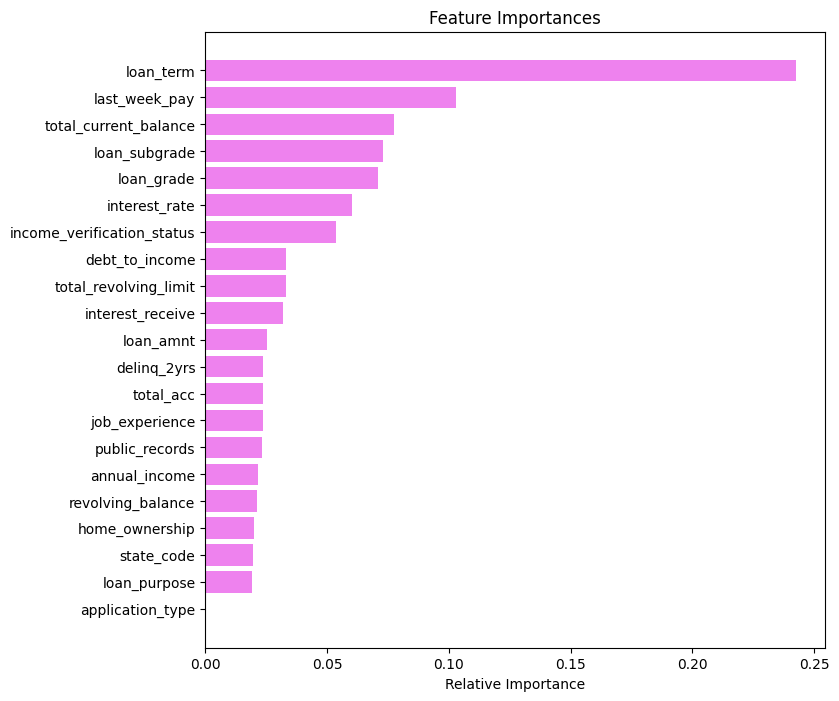

In [659]:
feature_names = list(X_train.columns)

importances = tuned_xgb_orig.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

# Working with the test data set to test our final model

In [660]:
df_test.columns

Index(['ID', 'loan_amnt', 'loan_term', 'interest_rate', 'loan_grade',
       'loan_subgrade', 'job_experience', 'home_ownership', 'annual_income',
       'income_verification_status', 'loan_purpose', 'state_code',
       'debt_to_income', 'delinq_2yrs', 'public_records', 'revolving_balance',
       'total_acc', 'interest_receive', 'application_type', 'last_week_pay',
       'total_current_balance', 'total_revolving_limit'],
      dtype='object')

#### Drop the ID column

In [661]:
#save the ID column
df_test_ID = df_test.ID
df_test_ID.info()

<class 'pandas.core.series.Series'>
RangeIndex: 39933 entries, 0 to 39932
Series name: ID
Non-Null Count  Dtype
--------------  -----
39933 non-null  int64
dtypes: int64(1)
memory usage: 312.1 KB


In [662]:
#df_test = df_test.drop(['ID','revolving_balance','public_records','delinq_2yrs'], axis=1)
df_test = df_test.drop(['ID'], axis=1)

**Let us do the same Encoding as in the training dataset**

In [663]:
df_test_1 = df_test.copy()

In [664]:
# From the above data we can see that there is only 1 data point for state code='ID'.
# The below code gives the row with state_code="ID".
# We can encode the State code to numerical column as shown below:

state_code = {'AK':0,  'AL':1,  'AR':2,  'AZ':3,  'CA':4 , 'CO':5,  'CT':6,  'DC':7,  'DE':8,
              'FL':9,  'GA':10, 'HI':11, 'IA':12, 'ID':13, 'IL':14, 'IN':15, 'KS':16, 'KY':17,
              'LA':18, 'MA':19, 'MD':20, 'ME':21, 'MI':22, 'MN':23, 'MO':24, 'MS':25, 'MT':26,
              'NC':27, 'ND':28, 'NE':29, 'NH':30, 'NJ':31, 'NM':32, 'NV':33, 'NY':34, 'OH':35,
              'OK':36, 'OR':37, 'PA':38, 'RI':39, 'SC':40, 'SD':41, 'TN':42, 'TX':43, 'UT':44,
              'VA':45, 'VT':46, 'WA':47, 'WI':48, 'WV':49, 'WY':50}
df_test_1['state_code'] = df_test_1['state_code'].map(state_code).astype('int64')



In [665]:
#Similarly, to avoid having too many column when we do one hot encoding, we can also convert the loan_subgrade into a numerical column as well.
loan_subgrade = {'A1':0,  'A2':1,  'A3':2,  'A4':3,  'A5':4,
                 'B1':5,  'B2':6,  'B3':7,  'B4':8,  'B5':9,
                 'C1':10, 'C2':11, 'C3':12, 'C4':13, 'C5':14,
                 'D1':15, 'D2':16, 'D3':17, 'D4':18, 'D5':19,
                 'E1':20, 'E2':21, 'E3':22, 'E4':23, 'E5':24,
                 'F1':25, 'F2':26, 'F3':27, 'F4':28, 'F5':29,
                 'G1':30, 'G2':31, 'G3':32, 'G4':33, 'G5':34}
df_test_1['loan_subgrade'] = df_test_1['loan_subgrade'].map(loan_subgrade).astype('int64')

In [666]:
#Sometimes if there are characters shuch as "<", there could be errors while using XGBoost.
job_experience = { np.NaN:0,'<5 Years':1, '6-10 years':2, '10+ years':3}
df_test_1['job_experience'] = df_test_1['job_experience'].map(job_experience).astype('int64')

In [667]:
loan_term = {'3 years': 0, '5 years': 1}
df_test_1['loan_term'] = df_test_1['loan_term'].map(loan_term).astype('int64')

loan_grade = {'A':0, 'B':1, 'C':2, 'D':3, 'E':4, 'F':5, 'G':6}
df_test_1['loan_grade'] = df_test_1['loan_grade'].map(loan_grade).astype('int64')

home_ownership = {'MORTGAGE':0, 'RENT':1, 'OWN':2, 'OTHER':3, 'NONE':4}
df_test_1['home_ownership'] = df_test_1['home_ownership'].map(home_ownership).astype('int64')

income_verification_status = {'Verified':0, 'Not Verified':1, 'Source Verified':2}
df_test_1['income_verification_status'] = df_test_1['income_verification_status'].map(income_verification_status).astype('int64')

loan_purpose = {'debt_consolidation': 0, 'credit_card':1, 'home_improvement': 2, 'other': 3}
df_test_1['loan_purpose'] = df_test_1['loan_purpose'].map(loan_purpose).astype('int64')

application_type = {'INDIVIDUAL': 0, 'JOINT':1}
df_test_1['application_type'] = df_test_1['application_type'].map(application_type).astype('int64')

In [668]:
df_test_1.isna().sum()

loan_amnt                        0
loan_term                        0
interest_rate                    0
loan_grade                       0
loan_subgrade                    0
job_experience                   0
home_ownership                   0
annual_income                    0
income_verification_status       0
loan_purpose                     0
state_code                       0
debt_to_income                   0
delinq_2yrs                      1
public_records                   1
revolving_balance                0
total_acc                        1
interest_receive                 0
application_type                 0
last_week_pay                  806
total_current_balance         3230
total_revolving_limit         3230
dtype: int64

In [669]:
# Treat the missing values in Numerical columns with missing values
df_test_1.annual_income.fillna(df_test_1.annual_income.median(), inplace=True)
df_test_1.delinq_2yrs.fillna(df_test_1.delinq_2yrs.median(), inplace=True)
df_test_1.public_records.fillna(df_test_1.public_records.median(), inplace=True)
df_test_1.last_week_pay.fillna(df_test_1.last_week_pay.median(), inplace=True)
df_test_1.total_current_balance.fillna(df_test_1.total_current_balance.median(), inplace=True)
df_test_1.total_revolving_limit.fillna(df_test_1.total_revolving_limit.median(), inplace=True)
df_test_1.total_acc.fillna(df_test_1.total_acc.median(), inplace=True)

**Check for missing values**

In [670]:
df_test_1.isna().sum()

loan_amnt                     0
loan_term                     0
interest_rate                 0
loan_grade                    0
loan_subgrade                 0
job_experience                0
home_ownership                0
annual_income                 0
income_verification_status    0
loan_purpose                  0
state_code                    0
debt_to_income                0
delinq_2yrs                   0
public_records                0
revolving_balance             0
total_acc                     0
interest_receive              0
application_type              0
last_week_pay                 0
total_current_balance         0
total_revolving_limit         0
dtype: int64

There are no more missing values in the test dataset.

#### Imputation

In [671]:
# Creating an instance of the SimpleImputer to take care of the missing values.
#imputer = SimpleImputer(strategy="most_frequent")
imputer = KNNImputer(n_neighbors=5)

#Impute the missing values in the columns Education, Marital_Status and the Income_Category columns
# in test dataset
null_col=["job_experience"]
# Fit and transform the train data
df_test_1[null_col] = imputer.fit_transform(df_test_1[null_col])

In [672]:
df_test_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39933 entries, 0 to 39932
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loan_amnt                   39933 non-null  int64  
 1   loan_term                   39933 non-null  int64  
 2   interest_rate               39933 non-null  float64
 3   loan_grade                  39933 non-null  int64  
 4   loan_subgrade               39933 non-null  int64  
 5   job_experience              39933 non-null  float64
 6   home_ownership              39933 non-null  int64  
 7   annual_income               39933 non-null  float64
 8   income_verification_status  39933 non-null  int64  
 9   loan_purpose                39933 non-null  int64  
 10  state_code                  39933 non-null  int64  
 11  debt_to_income              39933 non-null  float64
 12  delinq_2yrs                 39933 non-null  float64
 13  public_records              399

**Converting the object columns to Category**

In [673]:
cols = df_test_1.select_dtypes(include=["object"])

#Now convert these columns to type category
df_test_1[cols.columns] = (df_test_1[cols.columns]).astype("category")
df_test_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39933 entries, 0 to 39932
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loan_amnt                   39933 non-null  int64  
 1   loan_term                   39933 non-null  int64  
 2   interest_rate               39933 non-null  float64
 3   loan_grade                  39933 non-null  int64  
 4   loan_subgrade               39933 non-null  int64  
 5   job_experience              39933 non-null  float64
 6   home_ownership              39933 non-null  int64  
 7   annual_income               39933 non-null  float64
 8   income_verification_status  39933 non-null  int64  
 9   loan_purpose                39933 non-null  int64  
 10  state_code                  39933 non-null  int64  
 11  debt_to_income              39933 non-null  float64
 12  delinq_2yrs                 39933 non-null  float64
 13  public_records              399

#### Encoding categorical variables

In [674]:
## code to impute missing values in X_train
df_test_1 = pd.get_dummies(df_test_1, drop_first=True)

In [675]:
df_test_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39933 entries, 0 to 39932
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loan_amnt                   39933 non-null  int64  
 1   loan_term                   39933 non-null  int64  
 2   interest_rate               39933 non-null  float64
 3   loan_grade                  39933 non-null  int64  
 4   loan_subgrade               39933 non-null  int64  
 5   job_experience              39933 non-null  float64
 6   home_ownership              39933 non-null  int64  
 7   annual_income               39933 non-null  float64
 8   income_verification_status  39933 non-null  int64  
 9   loan_purpose                39933 non-null  int64  
 10  state_code                  39933 non-null  int64  
 11  debt_to_income              39933 non-null  float64
 12  delinq_2yrs                 39933 non-null  float64
 13  public_records              399

In [676]:
print("df_test_1 shape: ",df_test_1.shape)

df_test_1 shape:  (39933, 21)


In [677]:
# Let's check the performance on test set

final_test = tuned_xgb_orig.predict(df_test_1)
final_test


array([1, 0, 1, ..., 0, 0, 0])

In [678]:
print(len(final_test))

39933


In [679]:
final_prediction = {
    'ID': df_test_ID,
    'default': final_test
}
sample_submit_df = pd.DataFrame(final_prediction)
sample_submit_df.head()

,ID,default
0,4855329,1
1,66862420,0
2,3637416,1
3,53682249,0
4,53937165,0


In [680]:
sample_submit_df.to_csv('/content/drive/MyDrive/Python Course/Hackathon/sample_submission_17.csv', index=False)